# MMMU-Pro Eval300 × Gemma 4 26B-A4B IT — P3 Two-Call Plan-and-Solve

**Production, paper-oriented, API-only, two-stage and resume-safe evaluation notebook**

For every sample, the same hosted Gemma endpoint is called exactly twice when
both stages succeed:

1. **Plan call:** the complete multimodal multiple-choice problem is supplied
   with the Plan-and-Solve planning trigger.
2. **Execution call:** the complete problem and images are supplied again,
   together with the raw visible plan from call 1, and the model is instructed
   to carry out that plan step by step and finish with `Answer: $LETTER`.

The notebook preserves the frozen Eval300 cohort, model endpoint, generation
settings, parser, image encoding and marker-occurrence order used by the paired
baseline. It never sends gold answers or reference explanations. Planning and
final responses are independently checkpointed and validated on resume.

This is a deliberate **two-call adaptation** of Plan-and-Solve, not a claim of
exact replication of the original single-generation prompt protocol.


## Revision note — reconstruct Eval300 from a frozen ordered ID list

The evaluation subset is reconstructed from the official Hugging Face source:

```text
MMMU/MMMU_Pro / standard (10 options) / test
```

at the exact immutable source revision:

```text
563f3e84bb3b90893083a1f039cfa13077f2302b
```

The notebook first downloads all 1,730 rows in this source setting and then
performs exact ID lookup using `selected_ids.txt`. There is no re-sampling,
nearest-match lookup, question-text matching, or subject-based replacement.

The line order of `selected_ids.txt` is the evaluation order. Candidate options
are preserved row-faithfully:

- answer letters are derived dynamically from each row's actual option count;
- every option is preserved exactly as published;
- no option is padded, truncated, invented, or rewritten;
- every gold label must be valid for the row's actual choice set;
- the selected option-count distribution is archived.

Because the inference notebook receives only the frozen ID list (not the
few-shot pool), it does **not** claim to independently recompute few-shot
disjointness. That property belongs to the upstream dataset-construction stage.
This notebook instead proves that it evaluates the exact cryptographically
pinned ID list produced by that stage.


## Fixed P3 generation protocol

Both calls use the hosted Google API endpoint and the same frozen settings as
the paired baseline: temperature zero, no explicit top-p or top-k, 8192 output
tokens per call, seed 42, `thinking_level=minimal`, and non-streaming
generation. Call 2 receives the raw visible output of call 1 without semantic
editing. Only call 2 is scored.


# 0. Kaggle resume protocol

Attach the frozen `selected_ids.txt` input and enable Kaggle Internet. Store
the Google AI Studio key as `GEMINI_API_KEY` (preferred) or `GOOGLE_API_KEY`.
No GPU, GGUF, projector, CMake, or local model input is required.

To continue an interrupted P3 run, attach the previous notebook output.
`plan_results.jsonl` and `raw_results.jsonl` are resumed independently. Only
exact-signature checkpoints pass validation. A saved plan is reused verbatim;
only a missing stage is sent again.


# 1. Install/pin Python dependencies

This notebook uses Google's current Gen AI Python SDK:

```text
google-genai==2.21.0
```

The model itself is hosted by Google; no Gemma weights or vision projector are
downloaded. The pinned official MMMU-Pro source is downloaded later from
Hugging Face for exact Eval300 reconstruction.


In [1]:
import importlib.util, importlib.metadata, subprocess, sys

requirements = {
    "datasets": "datasets>=3.0",
    "huggingface_hub": "huggingface_hub>=0.24",
    "requests": "requests>=2.31",
    "sklearn": "scikit-learn>=1.3",
    "statsmodels": "statsmodels>=0.14",
    "PIL": "Pillow>=10",
    "pandas": "pandas>=2",
    "numpy": "numpy>=1.26",
    "matplotlib": "matplotlib>=3.8",
}

to_install = [
    spec for mod, spec in requirements.items()
    if importlib.util.find_spec(mod) is None
]

if to_install:
    print("Installing missing benchmark packages:", to_install)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *to_install]
    )

TARGET_GOOGLE_GENAI = "2.21.0"
try:
    current_google_genai = importlib.metadata.version("google-genai")
except importlib.metadata.PackageNotFoundError:
    current_google_genai = None

if current_google_genai != TARGET_GOOGLE_GENAI:
    print(
        "Pinning Google Gen AI SDK:",
        current_google_genai,
        "->",
        TARGET_GOOGLE_GENAI,
    )
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--upgrade",
        f"google-genai=={TARGET_GOOGLE_GENAI}",
    ])
else:
    print("google-genai already pinned:", current_google_genai)

print("No Gemma model weights are downloaded by this notebook.")


Pinning Google Gen AI SDK: 1.68.0 -> 2.21.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.0/260.0 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.6/472.6 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 52.9 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires google-auth==2.47.0, but you have google-auth 2.57.1 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-cloud-aiplatform 1.148.1 requires google-genai<2.0.0,>=1.66.0; python_version >= "3.10", but you have google-genai 2.21.0 which is incompatible.
google-adk 1.29.0 requires google-genai<2.0.0,>=1.64.0, but you have google-genai 2.21.0 which is incompatible.
gradio 5.50.0 requires pydantic<=2.12.3,>=2.0, but you have pydantic 2

No Gemma model weights are downloaded by this notebook.


# 2. Frozen experimental configuration

Both P3 calls use hosted `gemma-4-26b-a4b-it` through
`google-genai==2.21.0`, API version `v1beta`.

```text
Temperature             = 0.0
Top-p / top-k           = not explicitly sent
Max output tokens       = 8192 per call
Request seed            = 42
Gemma thinking          = minimal
Streaming               = no
Image transport         = lossless inline PNG Google Parts
Image order, both calls = exact MMMU-Pro marker-occurrence order
Call-1 injection        = raw visible response, verbatim
Primary parser          = deterministic final-line parser, call 2 only
```

Successful HTTP 200 content is an observation and is never regenerated because
it is long, truncated, malformed, or contains an answer. Infrastructure
failures remain incomplete and are retried by the audited scheduler.


In [2]:
import os, io, re, ast, json, time, math, base64, random, string, shutil
import hashlib, html, platform, subprocess, sys, shlex, threading, logging, importlib.metadata
from pathlib import Path
from datetime import datetime, timezone
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from PIL import Image
from tqdm.auto import tqdm
from datasets import load_dataset, Image as HFImage
from huggingface_hub import snapshot_download
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score,
    balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
    confusion_matrix,
)
from statsmodels.stats.proportion import proportion_confint

EXPERIMENT_ID = (
    "MMMUPro-Eval300__Gemma4-26B-A4B-IT__P3-TwoCallPlanAndSolve__"
    "GoogleGeminiAPI__RawPlanInjection__ValidatedTwoStageResume__"
    "Temp0__Seed42__MAX8192"
)
PROMPT_ID = "P3-TwoCallPlanAndSolve"
PROMPT_FAMILY = "Two-call Plan-and-Solve with raw plan injection"
EVALUATION_COHORT_ID = "MMMUPro-frozen-balanced-eval300-v1"

MODEL = "gemma-4-26b-a4b-it"
MODEL_API_NAME = MODEL
BASE_MODEL = "Gemma 4 26B A4B Instruct"
MODEL_ARCHITECTURE = "25.2B MoE / ~3.8B active"

PROVIDER = "Google Gemini Developer API / AI Studio Free Tier"
API_METHOD = "google-genai client.models.generate_content"
API_MODE = "hosted stateless API"
API_VERSION = "v1beta"
SDK_PACKAGE = "google-genai"
SDK_VERSION_PIN = "2.21.0"
SDK_PIN = f"google-genai=={SDK_VERSION_PIN}"
FREE_TIER_POLICY = "Gemma 4 input/output free of charge; project-specific rate limits apply"

DATASET_REPO = "MMMU/MMMU_Pro"
DATASET_CONFIG = "standard (10 options)"
DATASET_SUBDIR = "standard (10 options)"
DATASET_SPLIT = "test"
DATASET_REVISION = "563f3e84bb3b90893083a1f039cfa13077f2302b"
REVISION_SOURCE = "hard-pinned full Hugging Face commit SHA"
EXPECTED_SOURCE_N = 1730
EXPECTED_N = 300

EXPECTED_SOURCE_OPTION_COUNT_DISTRIBUTION = {
    2: 28, 3: 42, 4: 125, 5: 41, 6: 16, 7: 12,
    8: 31, 9: 221, 10: 1213, 12: 1,
}

SELECTION_PROTOCOL_NAME = (
    "fixed ordered selected_ids.txt; exact ID extraction from pinned official "
    "MMMU-Pro standard (10 options) test source; no resampling"
)
EXPECTED_SELECTED_IDS_CANONICAL_SHA256 = (
    "db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3"
)

INPUT_ROOT = Path("/kaggle/input")
if not INPUT_ROOT.exists():
    raise RuntimeError("/kaggle/input is missing; this notebook is intended for Kaggle.")


def canonical_id_text(ids):
    return "\n".join(ids) + "\n"


def canonical_id_sha256(ids):
    return hashlib.sha256(canonical_id_text(ids).encode("utf-8")).hexdigest()


def read_id_file_strict(path):
    text = Path(path).read_text(encoding="utf-8")
    lines = text.splitlines()

    if any((not line) or line != line.strip() for line in lines):
        raise RuntimeError(
            f"ID file contains blank lines or surrounding whitespace: {path}"
        )

    return lines, hashlib.sha256(Path(path).read_bytes()).hexdigest()


# Accept duplicate copies only if they resolve to the exact frozen ordered list.
all_selected_id_files = sorted({
    p.resolve()
    for p in INPUT_ROOT.rglob("selected_ids.txt")
    if p.is_file()
})

matching_id_files = []
id_file_diagnostics = []

for p in all_selected_id_files:
    try:
        ids_here, raw_sha_here = read_id_file_strict(p)
        canonical_sha_here = canonical_id_sha256(ids_here)
        id_file_diagnostics.append({
            "path": str(p),
            "rows": len(ids_here),
            "unique_rows": len(set(ids_here)),
            "raw_sha256": raw_sha_here,
            "canonical_sha256": canonical_sha_here,
        })
        if canonical_sha_here == EXPECTED_SELECTED_IDS_CANONICAL_SHA256:
            matching_id_files.append((p, ids_here, raw_sha_here))
    except Exception as e:
        id_file_diagnostics.append({
            "path": str(p),
            "error": repr(e),
        })

if not matching_id_files:
    raise RuntimeError(
        "No uploaded selected_ids.txt matches the frozen 300-ID selection.\n"
        f"Expected canonical SHA256: {EXPECTED_SELECTED_IDS_CANONICAL_SHA256}\n"
        f"Discovered files: {json.dumps(id_file_diagnostics, ensure_ascii=False, indent=2)}"
    )

# Multiple matching copies are scientifically equivalent; choose a stable path.
matching_id_files.sort(key=lambda x: str(x[0]))
SELECTED_IDS_PATH, selected_ids, SELECTED_IDS_RAW_SHA256 = matching_id_files[0]
SELECTED_IDS_CANONICAL_SHA256 = canonical_id_sha256(selected_ids)

if len(selected_ids) != EXPECTED_N:
    raise RuntimeError(
        f"selected_ids.txt rows={len(selected_ids)} != {EXPECTED_N}"
    )
if len(set(selected_ids)) != EXPECTED_N:
    raise RuntimeError("selected_ids.txt contains duplicate IDs.")

_id_pattern = re.compile(r"^(test|validation)_(.+)_([0-9]+)$")
id_subject_tokens = []
for sid in selected_ids:
    m = _id_pattern.fullmatch(sid)
    if not m:
        raise RuntimeError(f"Unexpected MMMU ID format: {sid!r}")
    id_subject_tokens.append(m.group(2))

id_subject_counts = Counter(id_subject_tokens)
if len(id_subject_counts) != 30:
    raise RuntimeError(
        f"Expected 30 subject tokens in selected_ids.txt; got {len(id_subject_counts)}"
    )
if set(id_subject_counts.values()) != {10}:
    raise RuntimeError(
        f"selected_ids.txt is not exactly 10 IDs per subject: {dict(id_subject_counts)}"
    )

if SELECTED_IDS_CANONICAL_SHA256 != EXPECTED_SELECTED_IDS_CANONICAL_SHA256:
    raise RuntimeError("Internal selected-ID canonical hash mismatch.")

API_SEED = 42
SEED_POLICY = "fixed_seed_all_requests_v1"

PROTOCOL_VERSION = 'P3_TWO_CALL_PLAN_AND_SOLVE_GEMMA4_26B_A4B_GOOGLE_API_EVAL300_RESUMESAFE_MAX8192_V1'
PARSER_VERSION = 'deterministic_final_line_answer_v1'
LOGGING_VERSION = "two_stage_live_per_request_full_error_v1"
SCHEDULING_VERSION = "two_stage_per_request_pacing_defer_timeout_then_long_retry_v1"
IMAGE_ENCODING_POLICY = 'lossless_png_inline_google_part_v1'
IMAGE_ORDER_POLICY = (
    "MMMU-Pro marker occurrence order in both calls; each occurrence emits its "
    "semantic label followed immediately by the matching image; repeated references repeat the image"
)
PLAN_UNIT_POLICY = "one successful planning call per sample_id"
PLAN_INJECTION_POLICY = "raw visible call-1 response injected verbatim into call 2"

TEMPERATURE = 0.0
TOP_P = None
TOP_K = None
MAX_TOKENS = 8192
PLAN_MAX_TOKENS = MAX_TOKENS
ANSWER_MAX_TOKENS = MAX_TOKENS
STREAM = False
NATIVE_THINKING = False
THINKING_LEVEL = "minimal"
REQUEST_SEED = API_SEED

# Google hosted API has no llama.cpp-style per-request ctx-size switch.
CTX_SIZE = None
CTX_SIZE_POLICY = "provider managed; no explicit context-size parameter sent"

INLINE_REQUEST_LIMIT_BYTES = 20 * 1024 * 1024
INLINE_REQUEST_SAFETY_BYTES = int(19.0 * 1024 * 1024)

assert TEMPERATURE == 0.0
assert API_SEED == 42
assert NATIVE_THINKING is False
assert THINKING_LEVEL == "minimal"
assert MAX_TOKENS == 8192

REQUEST_TIMEOUT_S = 1800
DEFERRED_REQUEST_TIMEOUT_S = 7200
REQUEST_TIMEOUT_MS = REQUEST_TIMEOUT_S * 1000
DEFERRED_REQUEST_TIMEOUT_MS = DEFERRED_REQUEST_TIMEOUT_S * 1000
SDK_INTERNAL_RETRY_ATTEMPTS = 1
MAX_ATTEMPTS = 3
DEFERRED_MAX_ATTEMPTS = MAX_ATTEMPTS
BASE_BACKOFF_S = 15.0
MAX_BACKOFF_S = 90.0
INTER_REQUEST_DELAY_S = 5.0
RETRYABLE_STATUS = {408, 409, 429, 500, 502, 503, 504}
DEFERRED_RETRY_PASSES = 1
MAX_CONSECUTIVE_EXHAUSTED_429 = 2
SOFT_WALLCLOCK_HOURS = 10.5

ARCHIVE_IMAGES = True
GENERATE_HTML_AUDIT = True
N_BOOTSTRAP = 2000
PRICE_INPUT_PER_1M_USD = 0.0
PRICE_OUTPUT_PER_1M_USD = 0.0

WORKDIR = Path('/kaggle/working/gemma4_26b_a4b_p3_two_call_plan_solve_google_api_eval300_MAX8192_v1')
MEDIA_DIR = WORKDIR / "media"
PLOTS_DIR = WORKDIR / "plots"
SOURCE_CACHE_ROOT = Path("/kaggle/working/mmmu_pro_source_pinned_563f3e84")

for p in (WORKDIR, MEDIA_DIR, PLOTS_DIR, SOURCE_CACHE_ROOT):
    p.mkdir(parents=True, exist_ok=True)

RAW = WORKDIR / "raw_results.jsonl"
PLAN_RAW = WORKDIR / "plan_results.jsonl"
EVENTS = WORKDIR / "api_events.jsonl"
SESSIONS = WORKDIR / "run_sessions.jsonl"
MANIFEST = WORKDIR / "run_manifest.json"
DSET_CSV = WORKDIR / "dataset_manifest.csv"
DSET_JSONL = WORKDIR / "dataset_manifest.jsonl"
INTEGRITY_JSON = WORKDIR / "dataset_integrity_audit.json"
SOURCE_PROVENANCE_JSON = WORKDIR / "source_dataset_provenance.json"
SELECTED_IDS_AUDIT_JSON = WORKDIR / "selected_ids_audit.json"
SELECTED_IDS_ARCHIVE = WORKDIR / "selected_ids.txt"
RESULTS_CSV = WORKDIR / "results_all.csv"
RESULTS_PARQUET = WORKDIR / "results_all.parquet"
PLAN_RESULTS_CSV = WORKDIR / "plans_all.csv"
ERROR_ANALYSIS_CSV = WORKDIR / "wrong_results_for_error_analysis.csv"
PARSER_AUDIT_CSV = WORKDIR / "parser_audit.csv"
SUMMARY_JSON = WORKDIR / "summary_metrics.json"
SUMMARY_CSV = WORKDIR / "summary_metrics.csv"
CLASS_CSV = WORKDIR / "class_metrics_all_choice_letters.csv"
SUBJECT_CSV = WORKDIR / "accuracy_by_subject.csv"
DOMAIN_CSV = WORKDIR / "accuracy_by_domain.csv"
DIFF_CSV = WORKDIR / "accuracy_by_difficulty.csv"
IMGTYPE_CSV = WORKDIR / "accuracy_by_image_type.csv"
IMGCOUNT_CSV = WORKDIR / "accuracy_by_image_count.csv"
AUDIT_HTML = WORKDIR / "audit_viewer.html"
README = WORKDIR / "README_RESULTS.md"
ENV_JSON = WORKDIR / "environment.json"
PIP_TXT = WORKDIR / "pip_freeze.txt"
MODEL_INFO_JSON = WORKDIR / "google_model_info.json"
PREFLIGHT_JSON = WORKDIR / "api_preflight.json"
DEFERRED_QUEUE_JSON = WORKDIR / "deferred_queue.json"
MISSING_IDS_TXT = WORKDIR / "missing_ids.txt"
MISSING_PLAN_IDS_JSON = WORKDIR / "missing_plan_ids.json"
CHECKPOINT_REPAIR_AUDIT = WORKDIR / "checkpoint_repair_audit.jsonl"

ALL_LETTERS = list(string.ascii_uppercase)
IMAGE_COLS = [f"image_{i}" for i in range(1, 8)]

# Archive the exact canonical ordered ID list used by this experiment.
SELECTED_IDS_ARCHIVE.write_text(
    canonical_id_text(selected_ids),
    encoding="utf-8",
)
selected_ids_audit = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "selected_ids_input_path": str(SELECTED_IDS_PATH),
    "matching_input_copies": [str(x[0]) for x in matching_id_files],
    "discovered_id_file_diagnostics": id_file_diagnostics,
    "rows": len(selected_ids),
    "unique_rows": len(set(selected_ids)),
    "raw_input_sha256": SELECTED_IDS_RAW_SHA256,
    "canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "expected_canonical_sha256": EXPECTED_SELECTED_IDS_CANONICAL_SHA256,
    "order_policy": "line order of canonical selected_ids.txt",
    "subject_token_counts": dict(sorted(id_subject_counts.items())),
}
SELECTED_IDS_AUDIT_JSON.write_text(
    json.dumps(selected_ids_audit, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

SESSION_START_MONO = time.monotonic()
SESSION_START_UTC = datetime.now(timezone.utc).isoformat()

logger = logging.getLogger("gemma4_26b_a4b_eval300_p3_google_api")
logger.setLevel(logging.INFO)
logger.handlers.clear()
_fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
_fh = logging.FileHandler(WORKDIR / "run.log", mode="a", encoding="utf-8")
_fh.setFormatter(_fmt)
logger.addHandler(_fh)
_sh = logging.StreamHandler(sys.stdout)
_sh.setFormatter(_fmt)
logger.addHandler(_sh)

print(EXPERIMENT_ID)
print("selected_ids input:", SELECTED_IDS_PATH)
print("selected_ids rows:", len(selected_ids))
print("selected_ids canonical SHA256:", SELECTED_IDS_CANONICAL_SHA256)
print("Matching identical selected_ids copies:", len(matching_id_files))
print("Output:", WORKDIR)


MMMUPro-Eval300__Gemma4-26B-A4B-IT__P3-TwoCallPlanAndSolve__GoogleGeminiAPI__RawPlanInjection__ValidatedTwoStageResume__Temp0__Seed42__MAX8192
selected_ids input: /kaggle/input/datasets/jingilifteyna/300-mmmu-pro/selected_ids.txt
selected_ids rows: 300
selected_ids canonical SHA256: db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
Matching identical selected_ids copies: 1
Output: /kaggle/working/gemma4_26b_a4b_p3_two_call_plan_solve_google_api_eval300_MAX8192_v1


# 3. Initialize the Google Gemini Developer API client

The notebook reads the API key from Kaggle Secrets without displaying it.

Accepted secret names, in order:

```text
GEMINI_API_KEY
GOOGLE_API_KEY
```

Exact endpoint:

```text
gemma-4-26b-a4b-it
```

The client is pinned to `google-genai==2.21.0`, API `v1beta`, a
30-minute HTTP timeout, and **SDK-internal retries disabled**. Retry behavior is
handled explicitly by this notebook so every attempt is auditable.


In [3]:
def sha_file(p, chunk_size=16 * 1024 * 1024):
    h = hashlib.sha256()
    with Path(p).open("rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


from google import genai
from google.genai import types

GOOGLE_GENAI_VERSION = importlib.metadata.version("google-genai")
if GOOGLE_GENAI_VERSION != SDK_VERSION_PIN:
    raise RuntimeError(
        f"google-genai version mismatch: {GOOGLE_GENAI_VERSION} != {SDK_VERSION_PIN}"
    )

# Read one API key without ever printing or persisting its value.
GOOGLE_API_KEY = None
GOOGLE_API_KEY_SOURCE = None

for secret_name in ("GEMINI_API_KEY", "GOOGLE_API_KEY"):
    try:
        from kaggle_secrets import UserSecretsClient
        value = UserSecretsClient().get_secret(secret_name)
    except Exception:
        value = None
    if value:
        GOOGLE_API_KEY = value.strip()
        GOOGLE_API_KEY_SOURCE = f"kaggle_secret:{secret_name}"
        break

if GOOGLE_API_KEY is None:
    for env_name in ("GEMINI_API_KEY", "GOOGLE_API_KEY"):
        value = os.environ.get(env_name)
        if value:
            GOOGLE_API_KEY = value.strip()
            GOOGLE_API_KEY_SOURCE = f"environment:{env_name}"
            break

if not GOOGLE_API_KEY:
    raise RuntimeError(
        "No Google API key found. In Kaggle, add a Secret named GEMINI_API_KEY "
        "(preferred) or GOOGLE_API_KEY, enable Internet, then rerun."
    )

def make_google_client(timeout_ms):
    return genai.Client(
        api_key=GOOGLE_API_KEY,
        http_options=types.HttpOptions(
            api_version=API_VERSION,
            timeout=int(timeout_ms),
            retry_options=types.HttpRetryOptions(
                attempts=SDK_INTERNAL_RETRY_ATTEMPTS,
            ),
        ),
    )


client = make_google_client(REQUEST_TIMEOUT_MS)
deferred_client = make_google_client(DEFERRED_REQUEST_TIMEOUT_MS)

print("✅ Google Gemini Developer API client initialized")
print("Model endpoint :", MODEL)
print("SDK            :", SDK_PIN)
print("API version    :", API_VERSION)
print("Key source     :", GOOGLE_API_KEY_SOURCE)
print("Key value      : [REDACTED]")
print("Thinking level :", THINKING_LEVEL)
print("Main timeout    :", REQUEST_TIMEOUT_S, "s")
print("Deferred timeout:", DEFERRED_REQUEST_TIMEOUT_S, "s")
print("No GPU/model-weight loading is required.")


✅ Google Gemini Developer API client initialized
Model endpoint : gemma-4-26b-a4b-it
SDK            : google-genai==2.21.0
API version    : v1beta
Key source     : kaggle_secret:GOOGLE_API_KEY
Key value      : [REDACTED]
Thinking level : minimal
Main timeout    : 1800 s
Deferred timeout: 7200 s
No GPU/model-weight loading is required.


# 4. Frozen P3 templates and immutable inference signature

Call 1 receives the complete multimodal problem and only the planning trigger.
Call 2 receives the complete problem again, the exact visible plan generated in
call 1, and the execution/answer scaffold. Parser identity is frozen separately
by the scoring signature.


In [4]:
PLAN_SUFFIX = "A: Let's first understand the problem and devise a plan to solve the problem."
EXECUTION_SUFFIX = "Answer the preceding multiple choice question.\nThe last line of your response should be of the following format:\n'Answer: $LETTER' (without quotes) where LETTER is one of options.\nlet's carry out the plan and solve the problem step by step.\nExplain your reasoning before answering."
PLAN_TEMPLATE_CANONICAL = "{ordered_image_parts}\n\n{question_text}\n\n{options}\n\nA: Let's first understand the problem and devise a plan to solve the problem."
FINAL_ANSWER_TEMPLATE_CANONICAL = "{ordered_image_parts}\n\n{question_text}\n\n{options}\n\nPlan generated in the preceding call:\n{plan_from_call_1}\n\nAnswer the preceding multiple choice question.\nThe last line of your response should be of the following format:\n'Answer: $LETTER' (without quotes) where LETTER is one of options.\nlet's carry out the plan and solve the problem step by step.\nExplain your reasoning before answering."

EXPECTED_PLAN_SUFFIX_SHA256 = '766a5e22674ee450f6365fa5091eb9a4209d3e97712c8c5f3a61502a5885ffb6'
EXPECTED_EXECUTION_SUFFIX_SHA256 = 'e59c1b1b8f910d2f45db6bdf00207b59fb8b77cc7c9b4c934ef239bb4afcbbe2'
EXPECTED_PLAN_TEMPLATE_SHA256 = '1a3eddf15039bb64413df44a14851281d98c7dbf88a1baac2637c3099f9fd429'
EXPECTED_FINAL_ANSWER_TEMPLATE_SHA256 = '2967fdef70943a601f451480455e7878a3b63841961598e17a826b48a457854b'

PLAN_SUFFIX_SHA256 = hashlib.sha256(PLAN_SUFFIX.encode("utf-8")).hexdigest()
EXECUTION_SUFFIX_SHA256 = hashlib.sha256(EXECUTION_SUFFIX.encode("utf-8")).hexdigest()
PLAN_TEMPLATE_SHA256 = hashlib.sha256(PLAN_TEMPLATE_CANONICAL.encode("utf-8")).hexdigest()
FINAL_ANSWER_TEMPLATE_SHA256 = hashlib.sha256(
    FINAL_ANSWER_TEMPLATE_CANONICAL.encode("utf-8")
).hexdigest()

assert PLAN_SUFFIX_SHA256 == EXPECTED_PLAN_SUFFIX_SHA256
assert EXECUTION_SUFFIX_SHA256 == EXPECTED_EXECUTION_SUFFIX_SHA256
assert PLAN_TEMPLATE_SHA256 == EXPECTED_PLAN_TEMPLATE_SHA256
assert FINAL_ANSWER_TEMPLATE_SHA256 == EXPECTED_FINAL_ANSWER_TEMPLATE_SHA256

# Compatibility aliases used by common reporting code.
PROMPT_SUFFIX = EXECUTION_SUFFIX
PROMPT_SUFFIX_SHA = EXECUTION_SUFFIX_SHA256
PROMPT_TEMPLATE_CANONICAL = FINAL_ANSWER_TEMPLATE_CANONICAL
PROMPT_TEMPLATE_SHA = FINAL_ANSWER_TEMPLATE_SHA256

sig_payload = {
    "experiment_id": EXPERIMENT_ID,
    "evaluation_cohort_id": EVALUATION_COHORT_ID,
    "prompt_id": PROMPT_ID,
    "prompt_family": PROMPT_FAMILY,
    "plan_suffix_sha256": PLAN_SUFFIX_SHA256,
    "execution_suffix_sha256": EXECUTION_SUFFIX_SHA256,
    "plan_template_sha256": PLAN_TEMPLATE_SHA256,
    "final_answer_template_sha256": FINAL_ANSWER_TEMPLATE_SHA256,
    "plan_unit_policy": PLAN_UNIT_POLICY,
    "plan_injection_policy": PLAN_INJECTION_POLICY,
    "model": MODEL,
    "base_model": BASE_MODEL,
    "provider": PROVIDER,
    "api_method": API_METHOD,
    "api_mode": API_MODE,
    "dataset_repo": DATASET_REPO,
    "dataset_config": DATASET_CONFIG,
    "dataset_split": DATASET_SPLIT,
    "dataset_revision": DATASET_REVISION,
    "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "selected_ids_count": len(selected_ids),
    "execution_order_policy": "all 300 lines of selected_ids.txt",
    "temperature": TEMPERATURE,
    "top_p": TOP_P,
    "top_k": TOP_K,
    "plan_max_tokens": PLAN_MAX_TOKENS,
    "answer_max_tokens": ANSWER_MAX_TOKENS,
    "ctx_size": CTX_SIZE,
    "seed": API_SEED,
    "stream": STREAM,
    "native_thinking": NATIVE_THINKING,
    "reasoning_control": "Google thinking_level=minimal; provider-native thinking rejected",
    "request_timeout_s": REQUEST_TIMEOUT_S,
    "deferred_request_timeout_s": DEFERRED_REQUEST_TIMEOUT_S,
    "max_attempts": MAX_ATTEMPTS,
    "deferred_max_attempts": DEFERRED_MAX_ATTEMPTS,
    "api_version": API_VERSION,
    "sdk_pin": SDK_PIN,
    "thinking_level": THINKING_LEVEL,
    "ctx_size_policy": CTX_SIZE_POLICY,
    "protocol_version": PROTOCOL_VERSION,
    "image_encoding_policy": IMAGE_ENCODING_POLICY,
    "image_order_policy": IMAGE_ORDER_POLICY,
}
EXPERIMENT_SIGNATURE = hashlib.sha256(
    json.dumps(sig_payload, sort_keys=True, separators=(",", ":")).encode("utf-8")
).hexdigest()

print("Plan suffix SHA256          :", PLAN_SUFFIX_SHA256)
print("Execution suffix SHA256     :", EXECUTION_SUFFIX_SHA256)
print("Plan template SHA256        :", PLAN_TEMPLATE_SHA256)
print("Final-answer template SHA256:", FINAL_ANSWER_TEMPLATE_SHA256)
print("Selected IDs SHA256         :", SELECTED_IDS_CANONICAL_SHA256)
print("Experiment signature        :", EXPERIMENT_SIGNATURE)


Plan suffix SHA256          : 766a5e22674ee450f6365fa5091eb9a4209d3e97712c8c5f3a61502a5885ffb6
Execution suffix SHA256     : e59c1b1b8f910d2f45db6bdf00207b59fb8b77cc7c9b4c934ef239bb4afcbbe2
Plan template SHA256        : 1a3eddf15039bb64413df44a14851281d98c7dbf88a1baac2637c3099f9fd429
Final-answer template SHA256: 2967fdef70943a601f451480455e7878a3b63841961598e17a826b48a457854b
Selected IDs SHA256         : db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
Experiment signature        : cfb2369248a10cad9ddd22d80c8cc17247755ea5e8f7860e55047a2f3682f761


# 5. Auto-discover an exact-signature two-stage checkpoint

Candidate outputs are ranked by completed final answers and then completed plan
calls. Both JSONL files are copied before record-level validation.


In [5]:
def read_jsonl(path, allow_incomplete_final_line=True):
    path = Path(path)
    if not path.exists():
        return []
    physical_lines = path.read_text(encoding="utf-8").splitlines()
    nonempty = [i for i, line in enumerate(physical_lines) if line.strip()]
    last_nonempty = nonempty[-1] if nonempty else None
    rows = []
    for zero_index, line in enumerate(physical_lines):
        if not line.strip():
            continue
        try:
            row = json.loads(line)
        except json.JSONDecodeError as exc:
            if allow_incomplete_final_line and zero_index == last_nonempty:
                print(
                    f"WARNING: ignoring one incomplete final JSONL line in {path} "
                    f"(physical line {zero_index + 1}): {exc}", flush=True,
                )
                break
            raise RuntimeError(
                f"Corrupt JSONL checkpoint {path} at physical line "
                f"{zero_index + 1}: {exc}"
            ) from exc
        if not isinstance(row, dict):
            raise RuntimeError(
                f"JSONL row is not an object in {path}, line {zero_index + 1}."
            )
        rows.append(row)
    return rows


def final_success_count(path):
    return len({
        row.get("sample_id") for row in read_jsonl(path)
        if row.get("api_ok") is True and row.get("sample_id")
    })


def plan_success_count(path):
    return len({
        row.get("sample_id") for row in read_jsonl(path)
        if row.get("api_ok") is True and row.get("sample_id")
    })


def repair_incomplete_final_jsonl_line(path):
    path = Path(path)
    if not path.exists():
        return False
    physical_lines = path.read_text(encoding="utf-8").splitlines(keepends=True)
    nonempty = [i for i, line in enumerate(physical_lines) if line.strip()]
    if not nonempty:
        return False
    last_index = nonempty[-1]
    try:
        json.loads(physical_lines[last_index])
        return False
    except json.JSONDecodeError as exc:
        rejected = physical_lines[last_index]
        kept = physical_lines[:last_index] + physical_lines[last_index + 1:]
        tmp = path.with_suffix(path.suffix + ".repairing")
        tmp.write_text("".join(kept), encoding="utf-8")
        os.replace(tmp, path)
        audit = {
            "repaired_utc": datetime.now(timezone.utc).isoformat(),
            "path": str(path),
            "action": "removed_incomplete_final_jsonl_fragment",
            "rejected_sha256": hashlib.sha256(rejected.encode("utf-8")).hexdigest(),
            "rejected_chars": len(rejected),
            "json_error": str(exc),
        }
        with CHECKPOINT_REPAIR_AUDIT.open("a", encoding="utf-8") as handle:
            handle.write(json.dumps(audit, ensure_ascii=False) + "\n")
            handle.flush()
            os.fsync(handle.fileno())
        print(f"Repaired one incomplete final fragment in {path}", flush=True)
        return True


if MANIFEST.exists():
    try:
        local_manifest = json.loads(MANIFEST.read_text(encoding="utf-8"))
    except Exception as exc:
        raise RuntimeError(f"Unreadable local manifest {MANIFEST}: {exc!r}")
    if local_manifest.get("experiment_signature") != EXPERIMENT_SIGNATURE:
        raise RuntimeError(
            "Existing /kaggle/working results belong to a different experiment. "
            "Start a clean Kaggle session."
        )


def discover_resume():
    candidates = []
    for manifest_path in INPUT_ROOT.rglob("run_manifest.json"):
        try:
            manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
        except Exception:
            continue
        if manifest.get("experiment_signature") != EXPERIMENT_SIGNATURE:
            continue
        base = manifest_path.parent
        final_path = base / "raw_results.jsonl"
        plan_path = base / "plan_results.jsonl"
        candidates.append((
            final_success_count(final_path),
            plan_success_count(plan_path),
            base,
            manifest,
        ))
    return sorted(candidates, key=lambda item: (item[0], item[1], str(item[2])), reverse=True)


candidates = discover_resume()
PRIOR_MANIFEST = None
RESUME_SOURCE = None
if candidates:
    for i, (n_final, n_plan, base, _) in enumerate(candidates[:10]):
        print(i, "final=", n_final, "plans=", n_plan, base)
    _, _, RESUME_SOURCE, PRIOR_MANIFEST = candidates[0]
    print("Using exact-signature P3 checkpoint:", RESUME_SOURCE)
    for name in [
        "raw_results.jsonl", "plan_results.jsonl",
        "api_events.jsonl", "run_sessions.jsonl",
    ]:
        src = RESUME_SOURCE / name
        dst = WORKDIR / name
        if src.exists() and not dst.exists():
            shutil.copy2(src, dst)
    if (RESUME_SOURCE / "media").exists():
        shutil.copytree(RESUME_SOURCE / "media", MEDIA_DIR, dirs_exist_ok=True)
else:
    print("No exact-signature P3 checkpoint found; starting a new run.")

for checkpoint_path in (RAW, PLAN_RAW, EVENTS, SESSIONS):
    repair_incomplete_final_jsonl_line(checkpoint_path)


No exact-signature P3 checkpoint found; starting a new run.


# 6. Download the pinned official 1,730-row source and reconstruct Eval300 by exact ID

This section downloads only the official MMMU-Pro source setting used by the
experiment:

```text
MMMU/MMMU_Pro
standard (10 options)
test
revision = 563f3e84bb3b90893083a1f039cfa13077f2302b
```

All source Parquet shards for this setting are downloaded before selection.
The source is hard-audited for row count, ID uniqueness, schema, option-count
profile, and valid gold labels.

The 300-row evaluation set is then reconstructed by **exact ID lookup** using
the uploaded `selected_ids.txt`, preserving its line order. No matching by
question text and no replacement/resampling is allowed.

The reconstructed subset is independently checked for:

- exactly 300 recovered IDs and no missing IDs;
- exact ID order equality to `selected_ids.txt`;
- 30 subjects × exactly 10 rows;
- expected final difficulty composition;
- valid row-level option/gold mappings;
- at least one image for every selected benchmark item.

The exact source shard sizes and SHA-256 values observed at runtime are archived
for provenance.


In [6]:
from collections import Counter

print("=" * 92)
print("MMMU-PRO PINNED SOURCE DOWNLOAD + EXACT ID RECONSTRUCTION")
print("=" * 92)
print("Repository            :", DATASET_REPO)
print("Physical setting      :", DATASET_SUBDIR)
print("Split                 :", DATASET_SPLIT)
print("Pinned revision       :", DATASET_REVISION)
print("Expected source rows  :", EXPECTED_SOURCE_N)
print("Selected ID rows      :", len(selected_ids))
print("Selected IDs SHA256   :", SELECTED_IDS_CANONICAL_SHA256)
print("Selection protocol    :", SELECTION_PROTOCOL_NAME)

try:
    snapshot_root = Path(
        snapshot_download(
            repo_id=DATASET_REPO,
            repo_type="dataset",
            revision=DATASET_REVISION,
            allow_patterns=[f"{DATASET_SUBDIR}/*.parquet"],
            local_dir=str(SOURCE_CACHE_ROOT),
        )
    )
except Exception as e:
    raise RuntimeError(
        "Failed to download the pinned official MMMU-Pro source. "
        "Ensure Kaggle Internet is enabled. "
        f"Repository={DATASET_REPO}, revision={DATASET_REVISION}. "
        f"Original error: {e!r}"
    ) from e

subset_dir = snapshot_root / DATASET_SUBDIR
parquet_files = sorted(subset_dir.glob(f"{DATASET_SPLIT}-*.parquet"))

if len(parquet_files) != 2:
    raise RuntimeError(
        "Pinned source should expose exactly two Standard-(10-options) test "
        f"Parquet shards; found {len(parquet_files)}: {parquet_files}"
    )

source_shards = []
for p in parquet_files:
    info = {
        "relative_path": str(p.relative_to(snapshot_root)),
        "size_bytes": int(p.stat().st_size),
        "sha256": sha_file(p),
    }
    source_shards.append(info)
    print(
        "Source shard:",
        info["relative_path"],
        f"| {info['size_bytes']/(1024**2):.2f} MiB",
        "| SHA256",
        info["sha256"],
    )

source_ds = load_dataset(
    "parquet",
    data_files={DATASET_SPLIT: [str(p) for p in parquet_files]},
    split=DATASET_SPLIT,
)

for col in IMAGE_COLS:
    if col in source_ds.column_names and not isinstance(source_ds.features[col], HFImage):
        source_ds = source_ds.cast_column(col, HFImage())


def choice_letters(n_options):
    n = int(n_options)
    if not (2 <= n <= len(ALL_LETTERS)):
        raise ValueError(f"Unsupported option count {n}.")
    return ALL_LETTERS[:n]


def _audit_parse_options(value):
    if isinstance(value, (list, tuple)):
        parsed = list(value)
    elif hasattr(value, "tolist") and not isinstance(value, str):
        parsed = value.tolist()
    elif isinstance(value, str):
        parsed = None
        for parser in (ast.literal_eval, json.loads):
            try:
                candidate = parser(value.strip())
                if isinstance(candidate, (list, tuple)):
                    parsed = list(candidate)
                    break
            except Exception:
                pass
        if parsed is None:
            raise ValueError(f"Could not parse options: {repr(value)[:300]}")
    else:
        raise TypeError(f"Unsupported options type: {type(value)}")

    return [str(v) for v in parsed]


required_source_columns = {
    "id", "question", "options", "answer", "subject",
    "topic_difficulty", "img_type", *IMAGE_COLS
}
missing_source_columns = required_source_columns - set(source_ds.column_names)
if missing_source_columns:
    raise RuntimeError(
        f"Pinned source missing required columns: {sorted(missing_source_columns)}"
    )

if len(source_ds) != EXPECTED_SOURCE_N:
    raise RuntimeError(
        f"Pinned source rows={len(source_ds)} != {EXPECTED_SOURCE_N}"
    )

source_ids = [str(x) for x in source_ds["id"]]
if len(set(source_ids)) != EXPECTED_SOURCE_N:
    raise RuntimeError("Pinned source IDs are not unique.")

source_option_dist = Counter()
source_invalid_gold = []
source_malformed_options = []

scalar_source = source_ds.select_columns(["id", "options", "answer"])
for idx, row in enumerate(scalar_source):
    try:
        opts = _audit_parse_options(row["options"])
        source_option_dist[len(opts)] += 1
        letters = choice_letters(len(opts))
        gold = str(row["answer"]).strip().upper()
        if gold not in letters:
            source_invalid_gold.append({
                "source_row_index": int(idx),
                "id": str(row["id"]),
                "gold": gold,
                "n_options": len(opts),
            })
    except Exception as e:
        source_malformed_options.append({
            "source_row_index": int(idx),
            "id": str(row["id"]),
            "error": repr(e),
        })

if dict(sorted(source_option_dist.items())) != EXPECTED_SOURCE_OPTION_COUNT_DISTRIBUTION:
    raise RuntimeError(
        "Pinned source option-count profile differs from the frozen expected "
        f"profile. Observed={dict(sorted(source_option_dist.items()))}, "
        f"expected={EXPECTED_SOURCE_OPTION_COUNT_DISTRIBUTION}"
    )

if source_malformed_options:
    raise RuntimeError(
        f"Pinned source contains malformed options: {source_malformed_options[:5]}"
    )
if source_invalid_gold:
    raise RuntimeError(
        f"Pinned source contains invalid gold labels: {source_invalid_gold[:5]}"
    )

source_index_by_id = {sid: i for i, sid in enumerate(source_ids)}
missing_selected_ids = [sid for sid in selected_ids if sid not in source_index_by_id]
if missing_selected_ids:
    raise RuntimeError(
        f"{len(missing_selected_ids)} selected IDs were not found in the pinned "
        f"official source. First missing IDs: {missing_selected_ids[:20]}"
    )

selected_source_indices = [
    int(source_index_by_id[sid])
    for sid in selected_ids
]

if len(set(selected_source_indices)) != EXPECTED_N:
    raise RuntimeError("Selected source indices are not unique.")

ds = source_ds.select(selected_source_indices)

# Add explicit provenance/order columns to the reconstructed subset.
if "source_row_index" in ds.column_names:
    ds = ds.remove_columns(["source_row_index"])
if "evaluation_order" in ds.column_names:
    ds = ds.remove_columns(["evaluation_order"])

ds = ds.add_column("source_row_index", selected_source_indices)
ds = ds.add_column("evaluation_order", list(range(1, EXPECTED_N + 1)))

recovered_ids = [str(x) for x in ds["id"]]
if recovered_ids != selected_ids:
    raise RuntimeError(
        "Exact-ID reconstruction order differs from selected_ids.txt."
    )

if canonical_id_sha256(recovered_ids) != EXPECTED_SELECTED_IDS_CANONICAL_SHA256:
    raise RuntimeError(
        "Reconstructed dataset ID hash differs from the frozen selected-ID hash."
    )

selected_subjects = [str(x) for x in ds["subject"]]
selected_subject_counts = Counter(selected_subjects)
if len(selected_subject_counts) != 30:
    raise RuntimeError(
        f"Reconstructed Eval300 has {len(selected_subject_counts)} subjects, expected 30."
    )
if set(selected_subject_counts.values()) != {10}:
    raise RuntimeError(
        "Reconstructed Eval300 is not exactly 10 rows per subject: "
        f"{dict(sorted(selected_subject_counts.items()))}"
    )

selection_frame = pd.DataFrame({
    "id": recovered_ids,
    "subject": selected_subjects,
    "difficulty": [str(x).strip().title() for x in ds["topic_difficulty"]],
    "source_row_index": selected_source_indices,
    "evaluation_order": list(range(1, EXPECTED_N + 1)),
})

actual_counts = (
    selection_frame.groupby(["subject", "difficulty"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Easy", "Medium", "Hard"], fill_value=0)
)

for subject in actual_counts.index:
    expected = {"Easy": 3, "Medium": 4, "Hard": 3}
    if subject == "Electronics":
        expected = {"Easy": 1, "Medium": 6, "Hard": 3}
    elif subject == "Literature":
        expected = {"Easy": 3, "Medium": 6, "Hard": 1}

    observed = {
        d: int(actual_counts.loc[subject, d])
        for d in ["Easy", "Medium", "Hard"]
    }
    if observed != expected:
        raise RuntimeError(
            f"Reconstructed Eval300 difficulty quota mismatch for {subject}: "
            f"observed={observed}, expected={expected}"
        )

selected_option_dist = Counter()
selected_invalid_gold = []
for idx, row in enumerate(ds.select_columns(["id", "options", "answer"])):
    opts = _audit_parse_options(row["options"])
    selected_option_dist[len(opts)] += 1
    letters = choice_letters(len(opts))
    gold = str(row["answer"]).strip().upper()
    if gold not in letters:
        selected_invalid_gold.append({
            "dataset_index": int(idx),
            "id": str(row["id"]),
            "gold": gold,
            "n_options": len(opts),
        })

if selected_invalid_gold:
    raise RuntimeError(
        f"Reconstructed Eval300 contains invalid gold labels: "
        f"{selected_invalid_gold[:5]}"
    )

source_provenance = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "repo": DATASET_REPO,
    "physical_setting": DATASET_SUBDIR,
    "split": DATASET_SPLIT,
    "revision": DATASET_REVISION,
    "revision_source": REVISION_SOURCE,
    "source_rows": len(source_ds),
    "source_unique_ids": len(set(source_ids)),
    "source_dataset_fingerprint": getattr(source_ds, "_fingerprint", None),
    "source_shards": source_shards,
    "source_option_count_distribution": {
        str(k): int(v) for k, v in sorted(source_option_dist.items())
    },
    "selected_ids_input_path": str(SELECTED_IDS_PATH),
    "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "selected_rows": len(ds),
    "selected_unique_ids": len(set(recovered_ids)),
    "selected_source_indices_sha256": hashlib.sha256(
        "|".join(map(str, selected_source_indices)).encode("utf-8")
    ).hexdigest(),
    "selected_dataset_fingerprint": getattr(ds, "_fingerprint", None),
    "selection_protocol": SELECTION_PROTOCOL_NAME,
}
SOURCE_PROVENANCE_JSON.write_text(
    json.dumps(source_provenance, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

audit = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "dataset_repo": DATASET_REPO,
    "dataset_config": DATASET_CONFIG,
    "split": DATASET_SPLIT,
    "dataset_revision": DATASET_REVISION,
    "source_rows": len(source_ds),
    "expected_source_rows": EXPECTED_SOURCE_N,
    "selected_rows": len(ds),
    "expected_selected_rows": EXPECTED_N,
    "selected_ids_raw_input_sha256": SELECTED_IDS_RAW_SHA256,
    "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "expected_selected_ids_canonical_sha256": EXPECTED_SELECTED_IDS_CANONICAL_SHA256,
    "selection_protocol": SELECTION_PROTOCOL_NAME,
    "execution_order_policy": "selected_ids.txt line order",
    "source_option_count_distribution": {
        str(k): int(v) for k, v in sorted(source_option_dist.items())
    },
    "selected_option_count_distribution": {
        str(k): int(v) for k, v in sorted(selected_option_dist.items())
    },
    "subject_counts": dict(sorted(selected_subject_counts.items())),
    "subject_difficulty_counts": {
        str(subject): {
            d: int(actual_counts.loc[subject, d])
            for d in ["Easy", "Medium", "Hard"]
        }
        for subject in actual_counts.index
    },
    "missing_selected_ids": missing_selected_ids,
    "n_invalid_gold_for_selected_rows": len(selected_invalid_gold),
    "selected_dataset_fingerprint": getattr(ds, "_fingerprint", None),
    "columns": list(ds.column_names),
    "features_repr": repr(ds.features),
    "fewshot_disjointness_note": (
        "Not independently recomputed in this inference notebook because the "
        "few-shot pool is not an input; the exact frozen upstream selection is "
        "instead pinned by selected_ids.txt canonical SHA-256."
    ),
}
INTEGRITY_JSON.write_text(
    json.dumps(audit, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("\n" + "=" * 92)
print("PINNED SOURCE + ID RECONSTRUCTION AUDIT: PASS")
print("=" * 92)
print("Source rows                    :", len(source_ds))
print("Source unique IDs              :", len(set(source_ids)))
print("Source option profile          :", dict(sorted(source_option_dist.items())))
print("Recovered rows                 :", len(ds))
print("Recovered unique IDs           :", len(set(recovered_ids)))
print("Recovered subjects             :", len(selected_subject_counts))
print("Rows per subject               :", sorted(set(selected_subject_counts.values())))
print("Selected IDs canonical SHA256  :", SELECTED_IDS_CANONICAL_SHA256)
print("Selected option profile        :", dict(sorted(selected_option_dist.items())))
print("Source dataset fingerprint     :", getattr(source_ds, "_fingerprint", None))
print("Selected dataset fingerprint   :", getattr(ds, "_fingerprint", None))
print("No resampling/replacement occurred.")
print("No model inference has occurred.")


MMMU-PRO PINNED SOURCE DOWNLOAD + EXACT ID RECONSTRUCTION
Repository            : MMMU/MMMU_Pro
Physical setting      : standard (10 options)
Split                 : test
Pinned revision       : 563f3e84bb3b90893083a1f039cfa13077f2302b
Expected source rows  : 1730
Selected ID rows      : 300
Selected IDs SHA256   : db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
Selection protocol    : fixed ordered selected_ids.txt; exact ID extraction from pinned official MMMU-Pro standard (10 options) test source; no resampling


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Source shard: standard (10 options)/test-00000-of-00002.parquet | 330.14 MiB | SHA256 0081991bf27dcd011a2cc0e455638ce2f983910cb5838f97f58f0a1e7589be0a
Source shard: standard (10 options)/test-00001-of-00002.parquet | 316.53 MiB | SHA256 8a9105607090e23bf61f747273de09a3dfd0dfca0e16fc5626c2737288a8aec8


Generating test split: 0 examples [00:00, ? examples/s]

Flattening the indices:   0%|          | 0/300 [00:00<?, ? examples/s]


PINNED SOURCE + ID RECONSTRUCTION AUDIT: PASS
Source rows                    : 1730
Source unique IDs              : 1730
Source option profile          : {2: 28, 3: 42, 4: 125, 5: 41, 6: 16, 7: 12, 8: 31, 9: 221, 10: 1213, 12: 1}
Recovered rows                 : 300
Recovered unique IDs           : 300
Recovered subjects             : 30
Rows per subject               : [10]
Selected IDs canonical SHA256  : db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
Selected option profile        : {2: 4, 3: 8, 4: 23, 5: 3, 6: 6, 7: 2, 8: 4, 9: 38, 10: 211, 12: 1}
Source dataset fingerprint     : 9e7183f0ca7a4915
Selected dataset fingerprint   : 6b6829e5696f4388
No resampling/replacement occurred.
No model inference has occurred.


In [7]:
# Paper-critical proof that the intended pinned source and exact ordered ID list are used.
assert DATASET_CONFIG == "standard (10 options)"
assert DATASET_SUBDIR == "standard (10 options)"
assert DATASET_SPLIT == "test"
assert DATASET_REVISION == "563f3e84bb3b90893083a1f039cfa13077f2302b"

assert len(source_ds) == EXPECTED_SOURCE_N == 1730
assert len(set(source_ids)) == 1730
assert len(ds) == EXPECTED_N == 300
assert len(set(recovered_ids)) == 300

assert SELECTED_IDS_CANONICAL_SHA256 == EXPECTED_SELECTED_IDS_CANONICAL_SHA256
assert recovered_ids == selected_ids
assert canonical_id_sha256(recovered_ids) == EXPECTED_SELECTED_IDS_CANONICAL_SHA256

assert len(selected_subject_counts) == 30
assert set(selected_subject_counts.values()) == {10}
assert not missing_selected_ids
assert not selected_invalid_gold

assert dict(sorted(source_option_dist.items())) == EXPECTED_SOURCE_OPTION_COUNT_DISTRIBUTION

print("✓ PINNED OFFICIAL SOURCE + EXACT 300-ID RECONSTRUCTION VERIFIED")
print("  Source revision       :", DATASET_REVISION)
print("  Source rows           :", len(source_ds))
print("  Selected rows         :", len(ds))
print("  Selected subjects     :", len(selected_subject_counts))
print("  Rows per subject      : 10")
print("  Selection policy      :", SELECTION_PROTOCOL_NAME)
print("  Selected IDs SHA256   :", SELECTED_IDS_CANONICAL_SHA256)
print("  Source option profile :", dict(sorted(source_option_dist.items())))
print("  Selected option profile:", dict(sorted(selected_option_dist.items())))


✓ PINNED OFFICIAL SOURCE + EXACT 300-ID RECONSTRUCTION VERIFIED
  Source revision       : 563f3e84bb3b90893083a1f039cfa13077f2302b
  Source rows           : 1730
  Selected rows         : 300
  Selected subjects     : 30
  Rows per subject      : 10
  Selection policy      : fixed ordered selected_ids.txt; exact ID extraction from pinned official MMMU-Pro standard (10 options) test source; no resampling
  Selected IDs SHA256   : db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
  Source option profile : {2: 28, 3: 42, 4: 125, 5: 41, 6: 16, 7: 12, 8: 31, 9: 221, 10: 1213, 12: 1}
  Selected option profile: {2: 4, 3: 8, 4: 23, 5: 3, 6: 6, 7: 2, 8: 4, 9: 38, 10: 211, 12: 1}


# 7. Archive images and construct the exact occurrence manifest

Every `<image n>` marker is classified by its location in the question or an
answer option. Both P3 calls emit images in this exact marker-occurrence order.
Repeated references remain repeated occurrences and therefore repeat the same
source image in the request.


In [8]:
def parse_options(x):
    if isinstance(x, (list, tuple)):
        options = list(x)
    elif hasattr(x, "tolist") and not isinstance(x, str):
        options = x.tolist()
    elif isinstance(x, str):
        options = None
        for parser in (ast.literal_eval, json.loads):
            try:
                candidate = parser(x.strip())
                if isinstance(candidate, (list, tuple)):
                    options = list(candidate)
                    break
            except Exception:
                pass
        if not isinstance(options, (list, tuple)):
            raise ValueError(f"Could not parse options: {repr(x)[:300]}")
    else:
        raise TypeError(f"Unsupported options type: {type(x)}")
    options = [str(value) for value in options]
    choice_letters(len(options))
    return options


def row_images(row):
    return [(col, row[col]) for col in IMAGE_COLS if col in row and row[col] is not None]


IMAGE_MARKER_RE = re.compile(r"<image\s+(\d+)>", flags=re.IGNORECASE)


def _ordered_unique(values):
    return list(dict.fromkeys(values))


def analyze_image_occurrences(row):
    options = parse_options(row["options"])
    letters = choice_letters(len(options))
    available = [int(col.split("_")[1]) for col, _ in row_images(row)]
    available_set = set(available)
    segments = [("question", None, str(row["question"]).strip())]
    segments.extend(("option", letter, option) for letter, option in zip(letters, options))

    refs_by_segment = {}
    for kind, option_letter, text in segments:
        refs_by_segment[(kind, option_letter)] = [
            int(match.group(1)) for match in IMAGE_MARKER_RE.finditer(text)
        ]
    all_refs = [ref for refs in refs_by_segment.values() for ref in refs]
    if not all_refs:
        raise RuntimeError(f"No <image n> marker found for sample {row['id']}")
    if set(all_refs) != available_set:
        raise RuntimeError(
            f"Image-marker/source mismatch for {row['id']}: refs={all_refs}, "
            f"available={available}"
        )

    question_unique = _ordered_unique(refs_by_segment[("question", None)])
    question_index = {ref: i + 1 for i, ref in enumerate(question_unique)}
    option_unique = {
        letter: _ordered_unique(refs_by_segment[("option", letter)])
        for letter in letters
    }

    occurrences = []
    for kind, option_letter, _ in segments:
        for segment_occurrence_index, ref in enumerate(
            refs_by_segment[(kind, option_letter)], start=1
        ):
            if kind == "question":
                ordinal = question_index[ref]
                image_label = f"Question Image {ordinal}"
                context_placeholder = f"[Question Image {ordinal}]"
            else:
                uniques = option_unique[option_letter]
                ordinal = uniques.index(ref) + 1
                if len(uniques) == 1:
                    image_label = f"Option {option_letter} Image"
                    context_placeholder = f"[visual option {option_letter}]"
                else:
                    image_label = f"Option {option_letter} Image {ordinal}"
                    context_placeholder = f"[visual option {option_letter} image {ordinal}]"
            occurrences.append({
                "occurrence_index": len(occurrences),
                "segment_occurrence_index": segment_occurrence_index,
                "image_ref": ref,
                "image_col": f"image_{ref}",
                "source_section": kind,
                "option_letter": option_letter,
                "image_label": image_label,
                "context_placeholder": context_placeholder,
            })
    return occurrences


def image_reference_order(row):
    return [item["image_ref"] for item in analyze_image_occurrences(row)]


def ordered_row_images(row):
    image_map = {int(col.split("_")[1]): (col, image) for col, image in row_images(row)}
    refs = image_reference_order(row)
    return [image_map[ref] for ref in refs], refs


def normalize_image_markers(text):
    return IMAGE_MARKER_RE.sub("<image>", str(text))


def safe_name(value):
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(value))[:180]


def prepare_image_for_send(image):
    sent = image.copy()
    source_mode = sent.mode
    if sent.mode == "P" and "transparency" in sent.info:
        sent = sent.convert("RGBA")
    elif sent.mode not in ("RGB", "RGBA", "L", "LA", "P"):
        sent = sent.convert("RGB")
    return sent, source_mode, sent.mode


def png_bytes(image):
    sent, _, _ = prepare_image_for_send(image)
    buffer = io.BytesIO()
    sent.save(buffer, format="PNG")
    return buffer.getvalue()


def archive_img(sample_id, col, image):
    sent, source_mode, sent_mode = prepare_image_for_send(image)
    buffer = io.BytesIO()
    sent.save(buffer, format="PNG")
    data = buffer.getvalue()
    digest = hashlib.sha256(data).hexdigest()
    filename = f"{safe_name(sample_id)}__{col}.png"
    path = MEDIA_DIR / filename
    if ARCHIVE_IMAGES and not path.exists():
        path.write_bytes(data)
    return {
        "image_col": col,
        "relative_path": f"media/{filename}",
        "width": int(sent.width),
        "height": int(sent.height),
        "source_mode": source_mode,
        "sent_mode": sent_mode,
        "encoding": "PNG",
        "png_bytes": len(data),
        "sha256": digest,
    }


order = list(range(len(ds)))
hf_ids = [str(value) for value in ds["id"]]
if hf_ids != selected_ids:
    raise RuntimeError("Reconstructed Eval300 order differs from selected_ids.txt.")
ORDER_SHA = hashlib.sha256("|".join(hf_ids).encode("utf-8")).hexdigest()
EXPECTED_ORDER_SHA = hashlib.sha256("|".join(selected_ids).encode("utf-8")).hexdigest()
if ORDER_SHA != EXPECTED_ORDER_SHA:
    raise RuntimeError("Selected-ID execution-order hash mismatch")

records = []
for execution_order, dataset_index in enumerate(tqdm(order, desc="Archiving P3 inputs")):
    row = ds[int(dataset_index)]
    options = parse_options(row["options"])
    letters = choice_letters(len(options))
    gold = str(row["answer"]).strip().upper()
    if gold not in letters:
        raise ValueError(f"Invalid gold {gold} for {row['id']}")
    image_meta = [archive_img(row["id"], col, image) for col, image in row_images(row)]
    if not image_meta:
        raise ValueError("No image: " + str(row["id"]))
    occurrences = analyze_image_occurrences(row)
    refs = [item["image_ref"] for item in occurrences]
    meta_by_ref = {int(item["image_col"].split("_")[1]): item for item in image_meta}
    ordered_meta = [meta_by_ref[ref] for ref in refs]
    estimated_payload = sum(4 * math.ceil(item["png_bytes"] / 3) for item in ordered_meta)

    records.append({
        "execution_order": execution_order,
        "dataset_index": int(dataset_index),
        "source_row_index": int(row["source_row_index"]),
        "sample_id": row["id"],
        "subject": row["subject"],
        "topic_difficulty": row["topic_difficulty"],
        "img_type": row["img_type"],
        "question": row["question"],
        "options": options,
        "n_options": len(options),
        "choice_letters": letters,
        "gold_answer": gold,
        "gold_option_text": options[letters.index(gold)],
        "gold_explanation": None,
        "image_count": len(image_meta),
        "image_occurrence_count": len(occurrences),
        "image_reference_order": refs,
        "image_block_columns": [item["image_col"] for item in occurrences],
        "image_occurrences": occurrences,
        "images": image_meta,
        "estimated_base64_image_bytes_per_call": int(estimated_payload),
        "api_seed": API_SEED,
        "seed_policy": SEED_POLICY,
    })

with DSET_JSONL.open("w", encoding="utf-8") as handle:
    for record in records:
        handle.write(json.dumps(record, ensure_ascii=False) + "\n")

flat = []
for record in records:
    flat.append({
        **{
            key: value for key, value in record.items()
            if key not in (
                "options", "images", "choice_letters", "image_reference_order",
                "image_block_columns", "image_occurrences",
            )
        },
        "options_json": json.dumps(record["options"], ensure_ascii=False),
        "choice_letters": "".join(record["choice_letters"]),
        "image_reference_order_json": json.dumps(record["image_reference_order"]),
        "image_block_columns": ";".join(record["image_block_columns"]),
        "image_occurrences_json": json.dumps(record["image_occurrences"], ensure_ascii=False),
        "image_files": ";".join(item["relative_path"] for item in record["images"]),
        "image_sha256": ";".join(item["sha256"] for item in record["images"]),
    })
pd.DataFrame(flat).to_csv(DSET_CSV, index=False)

print("Manifest rows:", len(records))
print("Order SHA:", ORDER_SHA)
print("Image occurrences per call:", sum(r["image_occurrence_count"] for r in records))
print("Rows with repeated image references:", sum(
    r["image_occurrence_count"] > r["image_count"] for r in records
))


Archiving P3 inputs:   0%|          | 0/300 [00:00<?, ?it/s]

Manifest rows: 300
Order SHA: 789bc1ac18805986f38c3aea51adaa5f33ac533e3398247170a4e4501e2605d3
Image occurrences per call: 348
Rows with repeated image references: 1


In [9]:
assert IMAGE_ENCODING_POLICY == "lossless_png_inline_google_part_v1"
for record in records:
    assert record["image_count"] == len(record["images"])
    assert record["image_occurrence_count"] == len(record["image_occurrences"])
    assert record["image_reference_order"] == [
        item["image_ref"] for item in record["image_occurrences"]
    ]
    assert record["image_block_columns"] == [
        item["image_col"] for item in record["image_occurrences"]
    ]
    assert set(record["image_block_columns"]) == {
        item["image_col"] for item in record["images"]
    }
print("P3 image occurrence manifest gate: PASS")


P3 image occurrence manifest gate: PASS


# 8. P3 prompt builders

Both calls place the semantic image label immediately before the matching image
and preserve exact marker-occurrence order. Call 2 repeats the full multimodal
problem and injects the raw visible plan after the question/options and before
the frozen execution scaffold.


In [10]:
def format_options(x):
    options = parse_options(x)
    return "\n".join(
        f"{letter}. {option}"
        for letter, option in zip(choice_letters(len(options)), options)
    )


def _replace_segment_markers(text, occurrences):
    placeholder_by_ref = {
        int(item["image_ref"]): item["context_placeholder"]
        for item in occurrences
    }
    return IMAGE_MARKER_RE.sub(
        lambda match: placeholder_by_ref[int(match.group(1))],
        str(text).strip(),
    )


def semantic_question_and_options(row):
    occurrences = analyze_image_occurrences(row)
    question_occurrences = [
        item for item in occurrences if item["source_section"] == "question"
    ]
    question_text = _replace_segment_markers(row["question"], question_occurrences)
    rendered_options = []
    options = parse_options(row["options"])
    for letter, option in zip(choice_letters(len(options)), options):
        option_occurrences = [
            item for item in occurrences
            if item["source_section"] == "option" and item["option_letter"] == letter
        ]
        rendered = _replace_segment_markers(option, option_occurrences)
        rendered_options.append(f"{letter}. {rendered}")
    return question_text, "\n".join(rendered_options)


def data_url(image):
    return "data:image/png;base64," + base64.b64encode(png_bytes(image)).decode("ascii")


def generation_config_dict(max_tokens):
    assert TEMPERATURE == 0.0 and TOP_P is None and TOP_K is None
    assert int(max_tokens) == MAX_TOKENS and NATIVE_THINKING is False
    assert THINKING_LEVEL == "minimal"
    return {
        "temperature": TEMPERATURE,
        "seed": int(API_SEED),
        "max_output_tokens": int(max_tokens),
        "thinking_level": THINKING_LEVEL,
        "stream": STREAM,
    }


def image_prefix_parts(row, meta):
    image_map = {col: image for col, image in row_images(row)}
    parts = []
    for occurrence in meta["image_occurrences"]:
        parts.extend([
            {"type": "text", "text": f"[{occurrence['image_label']}]"},
            {"type": "image_url", "image_url": {"url": data_url(image_map[occurrence["image_col"]])}},
        ])
    return parts


def plan_prompt_body(row):
    question_text, options_text = semantic_question_and_options(row)
    return f"{question_text}\n\n{options_text}\n\n{PLAN_SUFFIX}"


def plan_message(row, meta):
    return {
        "role": "user",
        "content": image_prefix_parts(row, meta) + [
            {"type": "text", "text": plan_prompt_body(row)}
        ],
    }


def plan_request_payload(row, meta):
    return {
        "model": MODEL_API_NAME,
        "messages": [plan_message(row, meta)],
        **generation_config_dict(PLAN_MAX_TOKENS),
    }


def plan_text(record):
    return str(record.get("plan_text", record.get("visible_response", "")) or "")


def final_answer_body(row, raw_plan):
    question_text, options_text = semantic_question_and_options(row)
    return (
        f"{question_text}\n\n{options_text}\n\n"
        f"Plan generated in the preceding call:\n{raw_plan}\n\n"
        f"{EXECUTION_SUFFIX}"
    )


def final_answer_message(row, meta, plan_record):
    return {
        "role": "user",
        "content": image_prefix_parts(row, meta) + [
            {"type": "text", "text": final_answer_body(row, plan_text(plan_record))}
        ],
    }


def canonical_message_text(message):
    chunks = []
    for part in message["content"]:
        chunks.append("<image>" if part["type"] == "image_url" else part["text"])
    return "\n\n".join(chunks)


def plan_full_prompt_text(row, meta):
    return canonical_message_text(plan_message(row, meta))


def final_answer_full_prompt_text(row, meta, plan_record):
    return canonical_message_text(final_answer_message(row, meta, plan_record))


def final_answer_request_payload(row, meta, plan_record):
    return {
        "model": MODEL_API_NAME,
        "messages": [final_answer_message(row, meta, plan_record)],
        **generation_config_dict(ANSWER_MAX_TOKENS),
    }


def diagnostic_payload_bytes(payload):
    return len(json.dumps(payload, ensure_ascii=False).encode("utf-8"))


def google_contents_from_message(message):
    parts = []
    for part in message["content"]:
        if part["type"] == "text":
            parts.append(types.Part.from_text(text=str(part["text"])))
            continue
        if part["type"] != "image_url":
            raise RuntimeError(f"Unsupported canonical part type: {part['type']!r}")
        url = str(part["image_url"]["url"])
        prefix = "data:image/png;base64,"
        if not url.startswith(prefix):
            raise RuntimeError("Only canonical inline PNG data URLs are accepted.")
        parts.append(types.Part.from_bytes(
            data=base64.b64decode(url[len(prefix):], validate=True),
            mime_type="image/png",
        ))
    return types.UserContent(parts=parts)


def google_generation_config(max_tokens):
    cfg = generation_config_dict(max_tokens)
    return types.GenerateContentConfig(
        temperature=cfg["temperature"],
        seed=cfg["seed"],
        max_output_tokens=cfg["max_output_tokens"],
        thinking_config=types.ThinkingConfig(thinking_level=cfg["thinking_level"]),
    )


# Full-cohort structural gate; no API call.
for meta in records:
    row = ds[int(meta["dataset_index"])]
    synthetic_plan = {"plan_text": "1. Inspect the relevant evidence.\n2. Compare the options."}
    pmsg = plan_message(row, meta)
    fmsg = final_answer_message(row, meta, synthetic_plan)
    expected_types = [
        item for _ in meta["image_occurrences"] for item in ("text", "image_url")
    ] + ["text"]
    assert [part["type"] for part in pmsg["content"]] == expected_types
    assert [part["type"] for part in fmsg["content"]] == expected_types
    for index, occurrence in enumerate(meta["image_occurrences"]):
        offset = index * 2
        assert pmsg["content"][offset]["text"] == f"[{occurrence['image_label']}]"
        assert fmsg["content"][offset]["text"] == f"[{occurrence['image_label']}]"
    assert pmsg["content"][-1]["text"].endswith(PLAN_SUFFIX)
    assert "Plan generated in the preceding call:\n" + synthetic_plan["plan_text"] in fmsg["content"][-1]["text"]
    assert fmsg["content"][-1]["text"].endswith("Explain your reasoning before answering.")

print("P3 two-call prompt and image-order gate: PASS for all 300 rows")


P3 two-call prompt and image-order gate: PASS for all 300 rows


# 9. Scoring parsers

**Primary:** strict final-line parser. Format failures are wrong.

**Secondary:** MMMU-Pro-style parser. The official evaluator has a random fallback when parsing fails; here that fallback is seeded per item so this secondary score is reproducible.


In [11]:
PARSER_SPEC_CANONICAL = (
    "primary=deterministic_last_nonempty_line_v1;"
    "accepted=Answer:LETTER|Answer:$LETTER|Answer:$LETTER$|Answer:(LETTER);"
    "optional_terminal_period=true;"
    "case_insensitive_primary=true;"
    "exact_format=Answer: LETTER;"
    "truncated=unparsed_and_wrong;"
    "fallback=none;"
    "gold_blind=true"
)
EXPECTED_PARSER_SPEC_SHA256 = (
    "750fb14154114a09fafa43cd2d48c53441b925210f6de044fdaa5fcf21e6fc73"
)
PARSER_SPEC_SHA256 = hashlib.sha256(
    PARSER_SPEC_CANONICAL.encode("utf-8")
).hexdigest()
if PARSER_SPEC_SHA256 != EXPECTED_PARSER_SPEC_SHA256:
    raise RuntimeError("Frozen parser specification hash mismatch.")
SCORING_SIGNATURE = hashlib.sha256(
    json.dumps(
        {
            "experiment_signature": EXPERIMENT_SIGNATURE,
            "parser_version": PARSER_VERSION,
            "parser_spec_sha256": PARSER_SPEC_SHA256,
        },
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")
).hexdigest()

PRIMARY_FINAL_LINE_PATTERNS = (
    ("plain_letter", re.compile(r"^Answer:\s*([A-Z])\s*\.?$", re.IGNORECASE)),
    ("dollar_prefix", re.compile(r"^Answer:\s*\$([A-Z])\s*\.?$", re.IGNORECASE)),
    ("latex_math", re.compile(r"^Answer:\s*\$([A-Z])\$\s*\.?$", re.IGNORECASE)),
    ("parenthesized", re.compile(r"^Answer:\s*\(([A-Z])\)\s*\.?$", re.IGNORECASE)),
)
EXACT_FORMAT_PATTERN = re.compile(r"^Answer: ([A-Z])$")


def _last_nonempty_line(text):
    lines = [line.strip() for line in str(text or "").splitlines() if line.strip()]
    return lines[-1] if lines else None


def answer_parse(text, all_choices):
    """Gold-blind primary parser; never scans or guesses from reasoning text."""
    final_line = _last_nonempty_line(text)
    if final_line is None:
        return None, "empty_response"

    for wrapper_name, pattern in PRIMARY_FINAL_LINE_PATTERNS:
        match = pattern.fullmatch(final_line)
        if match is None:
            continue
        prediction = match.group(1).upper()
        if prediction not in all_choices:
            return None, "final_line_letter_outside_row_choices"
        return prediction, f"final_line_{wrapper_name}"

    return None, "unparseable_final_line"


def exact_format_parse(text, all_choices):
    """Measure prompt-format compliance separately from answer correctness."""
    final_line = _last_nonempty_line(text)
    if final_line is None:
        return None, "empty_response"
    match = EXACT_FORMAT_PATTERN.fullmatch(final_line)
    if match is None:
        return None, "exact_format_failure"
    prediction = match.group(1)
    if prediction not in all_choices:
        return None, "exact_format_letter_outside_row_choices"
    return prediction, "exact_requested_format"


def official_style_parse(response, options, sample_id=None):
    choices = choice_letters(len(options))
    option_by_letter = dict(zip(choices, options))
    response = response if isinstance(response, str) else ""

    pos = response.rfind("Answer:")
    if pos != -1:
        suffix = response[pos + len("Answer:"):].strip()
        hits = [choice for choice in choices if choice in suffix]
        if len(hits) == 1:
            return hits[0], "answer_colon_unique"

    stripped = response
    for char in [",", ".", "!", "?", ";", ":", "'"]:
        stripped = stripped.strip(char)
    padded = " " + stripped + " "
    candidates = []
    index_answer = True
    bracket = False

    for choice in choices:
        if f"({choice})" in padded:
            candidates.append(choice)
            bracket = True
    if not candidates:
        for choice in choices:
            if f"{choice} " in padded:
                candidates.append(choice)
    if not candidates:
        for choice in choices:
            if f"{choice}." in padded:
                candidates.append(choice)
    if not candidates and len(padded.split()) > 5:
        for choice, option in option_by_letter.items():
            if str(option).lower() in padded.lower():
                candidates.append(choice)
        index_answer = False

    if not candidates:
        return None, "no_match_no_fallback"
    if len(candidates) > 1:
        if index_answer:
            positions = [
                padded.rfind(f"({choice})") if bracket
                else padded.rfind(f" {choice} ")
                for choice in candidates
            ]
        else:
            positions = [
                padded.lower().rfind(str(option_by_letter[choice]).lower())
                for choice in candidates
            ]
        return candidates[int(np.argmax(positions))], "last_candidate"
    return candidates[0], "single_candidate"


for _text in ("Answer: C", "Answer: $C", "Answer: $C$", "Answer: (C)", "Answer: C."):
    assert answer_parse("reasoning\n" + _text, list("ABCDEFGHIJ"))[0] == "C"
assert answer_parse("reasoning\nAnswer: $K", list("ABCDEFGHIJKL"))[0] == "K"
assert answer_parse("reasoning\nAnswer: $K", list("ABCDEFGHIJ"))[0] is None
assert answer_parse("Answer: C\nextra text", list("ABCDEFGHIJ"))[0] is None
assert answer_parse("The answer is C", list("ABCDEFGHIJ"))[0] is None
assert exact_format_parse("reasoning\nAnswer: C", list("ABCDEFGHIJ"))[0] == "C"
assert exact_format_parse("reasoning\nAnswer: $C", list("ABCDEFGHIJ"))[0] is None
assert exact_format_parse("reasoning\nAnswer: $C$", list("ABCDEFGHIJ"))[0] is None
assert official_style_parse("unparseable", ["a", "b"])[0] is None
print("Frozen deterministic parser tests: PASS")
print("Parser version:", PARSER_VERSION)
print("Parser specification SHA256:", PARSER_SPEC_SHA256)
print("Scoring signature:", SCORING_SIGNATURE)
print("No parser uses a random fallback for headline scoring.")


Frozen deterministic parser tests: PASS
Parser version: deterministic_final_line_answer_v1
Parser specification SHA256: 750fb14154114a09fafa43cd2d48c53441b925210f6de044fdaa5fcf21e6fc73
Scoring signature: 565eacf87117772301d228b24e96746b032fd9ddd40a4e33d4f3590227389090
No parser uses a random fallback for headline scoring.


# 10. Environment and immutable run manifest

The manifest records the exact endpoint, API/SDK version, key-source name
(never the key), both prompt hashes, plan injection rule, ordered Eval300
identity, generation settings, scheduling, parser, and dataset provenance.


In [12]:
def obj_get(obj, name, default=None):
    if obj is None:
        return default
    if isinstance(obj, dict):
        return obj.get(name, default)
    return getattr(obj, name, default)


try:
    PIP_TXT.write_text(
        subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True),
        encoding="utf-8",
    )
except Exception as e:
    PIP_TXT.write_text(repr(e), encoding="utf-8")

nb_candidates = list(Path("/kaggle/working").glob("*.ipynb"))
nb_info = None
if nb_candidates:
    try:
        nb_info = {"path": str(nb_candidates[0]), "sha256": sha_file(nb_candidates[0])}
    except Exception:
        pass

env = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "python": platform.python_version(),
    "platform": platform.platform(),
    "notebook": nb_info,
    "provider": PROVIDER,
    "api_version": API_VERSION,
    "sdk": SDK_PIN,
    "api_key_source": GOOGLE_API_KEY_SOURCE,
    "api_key_value_archived": False,
}
ENV_JSON.write_text(json.dumps(env, ensure_ascii=False, indent=2), encoding="utf-8")

model_info_dict = {
    "model_endpoint": MODEL,
    "model_name": BASE_MODEL,
    "model_architecture": MODEL_ARCHITECTURE,
    "provider": PROVIDER,
    "api_method": API_METHOD,
    "api_mode": API_MODE,
    "api_version": API_VERSION,
    "sdk": SDK_PIN,
    "free_tier_policy": FREE_TIER_POLICY,
    "thinking_level": THINKING_LEVEL,
    "native_thinking_enabled": NATIVE_THINKING,
    "max_output_tokens_per_call": MAX_TOKENS,
    "temperature": TEMPERATURE,
    "top_p_sent": False,
    "top_k_sent": False,
    "seed": API_SEED,
    "ctx_size_policy": CTX_SIZE_POLICY,
    "image_transport": "inline PNG bytes",
    "image_encoding_policy": IMAGE_ENCODING_POLICY,
}
MODEL_INFO_JSON.write_text(
    json.dumps(model_info_dict, ensure_ascii=False, indent=2), encoding="utf-8"
)

created = (PRIOR_MANIFEST or {}).get("created_utc") or datetime.now(timezone.utc).isoformat()
run_manifest = {
    "experiment_id": EXPERIMENT_ID,
    "experiment_signature": EXPERIMENT_SIGNATURE,
    "protocol_version": PROTOCOL_VERSION,
    "logging_version": LOGGING_VERSION,
    "scheduling_version": SCHEDULING_VERSION,
    "created_utc": created,
    "current_version_started_utc": SESSION_START_UTC,
    "model_requested": MODEL,
    "base_model": BASE_MODEL,
    "model_architecture": MODEL_ARCHITECTURE,
    "provider": PROVIDER,
    "api_method": API_METHOD,
    "api_mode": API_MODE,
    "api_version": API_VERSION,
    "sdk_pin": SDK_PIN,
    "free_tier_policy": FREE_TIER_POLICY,
    "provider_model_info_file": MODEL_INFO_JSON.name,
    "api_key_source_name": GOOGLE_API_KEY_SOURCE,
    "api_key_value_archived": False,
    "dataset_repo": DATASET_REPO,
    "dataset_config": DATASET_CONFIG,
    "dataset_physical_setting": DATASET_SUBDIR,
    "dataset_split": DATASET_SPLIT,
    "dataset_revision": DATASET_REVISION,
    "dataset_revision_source": REVISION_SOURCE,
    "source_dataset_rows": len(source_ds),
    "source_dataset_unique_ids": len(set(source_ids)),
    "source_dataset_fingerprint": getattr(source_ds, "_fingerprint", None),
    "source_shards": source_shards,
    "source_provenance_file": SOURCE_PROVENANCE_JSON.name,
    "selected_rows": len(ds),
    "selected_dataset_fingerprint": getattr(ds, "_fingerprint", None),
    "selected_ids_input_file": str(SELECTED_IDS_PATH),
    "selected_ids_archived_file": SELECTED_IDS_ARCHIVE.name,
    "selected_ids_raw_input_sha256": SELECTED_IDS_RAW_SHA256,
    "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "selected_ids_expected_canonical_sha256": EXPECTED_SELECTED_IDS_CANONICAL_SHA256,
    "selected_ids_audit_file": SELECTED_IDS_AUDIT_JSON.name,
    "selection_protocol": SELECTION_PROTOCOL_NAME,
    "execution_order_policy": "selected_ids.txt line order",
    "execution_order_sha256": ORDER_SHA,
    "paired_expected_execution_order_sha256": EXPECTED_ORDER_SHA,
    "dataset_integrity_audit_file": INTEGRITY_JSON.name,
    "selected_subject_counts": dict(sorted(selected_subject_counts.items())),
    "selected_subject_difficulty_counts": audit["subject_difficulty_counts"],
    "option_count_distribution": audit["selected_option_count_distribution"],
    "prompt_id": PROMPT_ID,
    "prompt_family": PROMPT_FAMILY,
    "plan_suffix": PLAN_SUFFIX,
    "plan_suffix_sha256": PLAN_SUFFIX_SHA256,
    "execution_suffix": EXECUTION_SUFFIX,
    "execution_suffix_sha256": EXECUTION_SUFFIX_SHA256,
    "plan_template_canonical": PLAN_TEMPLATE_CANONICAL,
    "plan_template_sha256": PLAN_TEMPLATE_SHA256,
    "final_answer_template_canonical": FINAL_ANSWER_TEMPLATE_CANONICAL,
    "final_answer_template_sha256": FINAL_ANSWER_TEMPLATE_SHA256,
    "plan_unit_policy": PLAN_UNIT_POLICY,
    "plan_injection_policy": PLAN_INJECTION_POLICY,
    "question_prefix_added": False,
    "zero_shot": True,
    "examples_or_demonstrations_provided": False,
    "p3_is_two_call_adaptation_not_exact_original_ps_replication": True,
    "temperature_requested": TEMPERATURE,
    "top_p_requested": TOP_P,
    "top_k_requested": TOP_K,
    "top_p_sent": False,
    "top_k_sent": False,
    "max_output_tokens_per_call": MAX_TOKENS,
    "api_seed": API_SEED,
    "seed_policy": SEED_POLICY,
    "streaming": STREAM,
    "ctx_size_policy": CTX_SIZE_POLICY,
    "provider_reasoning_control_requested": True,
    "thinking_level_requested": THINKING_LEVEL,
    "native_thinking_enabled": NATIVE_THINKING,
    "visible_explanation_requested_in_final_call": True,
    "request_timeout_s": REQUEST_TIMEOUT_S,
    "deferred_request_timeout_s": DEFERRED_REQUEST_TIMEOUT_S,
    "http_request_timeout_ms": REQUEST_TIMEOUT_MS,
    "deferred_http_request_timeout_ms": DEFERRED_REQUEST_TIMEOUT_MS,
    "sdk_internal_retry_attempts": SDK_INTERNAL_RETRY_ATTEMPTS,
    "retry_policy": {
        "max_attempts_per_pass": MAX_ATTEMPTS,
        "base_backoff_s": BASE_BACKOFF_S,
        "max_backoff_s": MAX_BACKOFF_S,
        "deferred_retry_passes": DEFERRED_RETRY_PASSES,
        "retryable_status_codes": sorted(RETRYABLE_STATUS),
        "never_retry_successful_provider_response_for_content": True,
        "applies_to_plan_and_final_answer_stages": True,
    },
    "inter_request_delay_s": INTER_REQUEST_DELAY_S,
    "max_consecutive_exhausted_429": MAX_CONSECUTIVE_EXHAUSTED_429,
    "soft_wallclock_hours": SOFT_WALLCLOCK_HOURS,
    "input_order_both_calls": "per occurrence: semantic label, matching image; then question/options",
    "image_marker_normalization": "semantic labels in question/options",
    "repeated_reference_policy": "repeat the referenced image at every marker occurrence",
    "image_encoding": "lossless PNG inline bytes in Google Part objects",
    "image_encoding_policy": IMAGE_ENCODING_POLICY,
    "inline_request_limit_bytes_documented": INLINE_REQUEST_LIMIT_BYTES,
    "inline_request_safety_gate_bytes": INLINE_REQUEST_SAFETY_BYTES,
    "gold_answer_sent": False,
    "gold_explanation_sent": False,
    "source_reference_explanation_used_in_prompt": False,
    "call1_raw_visible_text_passed_to_call2": True,
    "plan_content_validity_is_diagnostic_not_retry_trigger": True,
    "only_final_call_scored": True,
    "primary_parser": "frozen deterministic last non-empty line: Answer: [$]LETTER",
    "secondary_parser": "official-style diagnostic only; no random fallback and never headline",
    "resume_source": str(RESUME_SOURCE) if RESUME_SOURCE else None,
    "price_input_per_1m_usd": PRICE_INPUT_PER_1M_USD,
    "price_output_per_1m_usd": PRICE_OUTPUT_PER_1M_USD,
    "environment": env,
}
MANIFEST.write_text(json.dumps(run_manifest, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(run_manifest, ensure_ascii=False, indent=2)[:10000])


{
  "experiment_id": "MMMUPro-Eval300__Gemma4-26B-A4B-IT__P3-TwoCallPlanAndSolve__GoogleGeminiAPI__RawPlanInjection__ValidatedTwoStageResume__Temp0__Seed42__MAX8192",
  "experiment_signature": "cfb2369248a10cad9ddd22d80c8cc17247755ea5e8f7860e55047a2f3682f761",
  "protocol_version": "P3_TWO_CALL_PLAN_AND_SOLVE_GEMMA4_26B_A4B_GOOGLE_API_EVAL300_RESUMESAFE_MAX8192_V1",
  "logging_version": "two_stage_live_per_request_full_error_v1",
  "scheduling_version": "two_stage_per_request_pacing_defer_timeout_then_long_retry_v1",
  "created_utc": "2026-09-04T22:13:57.016842+00:00",
  "current_version_started_utc": "2026-09-04T22:11:55.524895+00:00",
  "model_requested": "gemma-4-26b-a4b-it",
  "base_model": "Gemma 4 26B A4B Instruct",
  "model_architecture": "25.2B MoE / ~3.8B active",
  "provider": "Google Gemini Developer API / AI Studio Free Tier",
  "api_method": "google-genai client.models.generate_content",
  "api_mode": "hosted stateless API",
  "api_version": "v1beta",
  "sdk_pin": "google-

# 11. Audited two-stage Google hosted API client

Both stages call `client.models.generate_content` on
`gemma-4-26b-a4b-it`. Canonical messages are converted to Google Part objects
without changing `label → image` occurrence order. No local model, GPU runtime,
GGUF projector, CMake build, or localhost server is used.


In [13]:
LAST_REQUEST_STARTED_MONO = None

def append_jsonl(path, obj):
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(obj, ensure_ascii=False, default=str) + "\n")
        f.flush()
        os.fsync(f.fileno())


def live_log(message):
    ts = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")
    print(f"[{ts}] {message}", flush=True)
    logger.info(message)


def _safe_error_text(exc, max_chars=10000):
    text = str(exc)
    return text if len(text) <= max_chars else text[:max_chars] + " ...[truncated]"


def _enum_text(value):
    if value is None:
        return None
    v = getattr(value, "value", None)
    if v is not None:
        return str(v)
    return str(value)


def _status_from_exception(exc):
    for name in ("status_code", "code"):
        value = getattr(exc, name, None)
        if value is not None:
            try:
                return int(value)
            except Exception:
                try:
                    return int(getattr(value, "value"))
                except Exception:
                    pass

    response = getattr(exc, "response", None)
    if response is not None:
        value = getattr(response, "status_code", None)
        if value is not None:
            try:
                return int(value)
            except Exception:
                pass

    text = str(exc)
    m = re.search(r"\b(4\d\d|5\d\d)\b", text)
    return int(m.group(1)) if m else None


def _retry_after_seconds(exc, fallback):
    response = getattr(exc, "response", None)
    headers = getattr(response, "headers", None) if response is not None else None
    if headers:
        try:
            value = headers.get("retry-after") or headers.get("Retry-After")
            if value is not None:
                return max(float(value), fallback)
        except Exception:
            pass

    text = str(exc)
    for pat in (
        r"retry(?:Delay| after)?[^0-9]{0,20}([0-9]+(?:\.[0-9]+)?)\s*s",
        r"Please retry in ([0-9]+(?:\.[0-9]+)?)s",
    ):
        m = re.search(pat, text, flags=re.IGNORECASE)
        if m:
            return max(float(m.group(1)), fallback)

    return fallback


def _response_to_jsonable(response):
    try:
        return response.model_dump(mode="json", exclude_none=True)
    except Exception:
        try:
            return response.to_json_dict()
        except Exception:
            return {"repr": repr(response)[:20000]}


def _extract_google_response(response):
    visible_parts = []
    thought_parts = []

    candidates = obj_get(response, "candidates", None) or []
    first_candidate = candidates[0] if candidates else None
    content = obj_get(first_candidate, "content", None)
    parts = obj_get(content, "parts", None) or []

    for part in parts:
        text = obj_get(part, "text", None)
        if text is None:
            continue
        if bool(obj_get(part, "thought", False)):
            thought_parts.append(str(text))
        else:
            visible_parts.append(str(text))

    # response.text is a convenience property; use only as a fallback.
    visible = "".join(visible_parts).strip()
    if not visible:
        try:
            visible = str(response.text or "").strip()
        except Exception:
            visible = ""

    reasoning = "\n".join(thought_parts).strip()

    usage = obj_get(response, "usage_metadata", None)
    prompt_tokens = obj_get(usage, "prompt_token_count", None)
    completion_tokens = obj_get(usage, "candidates_token_count", None)
    if completion_tokens is None:
        completion_tokens = obj_get(usage, "response_token_count", None)
    reasoning_tokens = obj_get(usage, "thoughts_token_count", None)
    total_tokens = obj_get(usage, "total_token_count", None)

    finish_reason = _enum_text(obj_get(first_candidate, "finish_reason", None))
    model_version = obj_get(response, "model_version", None)
    response_id = obj_get(response, "response_id", None)

    prompt_feedback = obj_get(response, "prompt_feedback", None)
    block_reason = _enum_text(obj_get(prompt_feedback, "block_reason", None))

    return {
        "visible": visible,
        "reasoning": reasoning,
        "prompt_tokens": prompt_tokens,
        "completion_tokens": completion_tokens,
        "reasoning_tokens": reasoning_tokens,
        "total_tokens": total_tokens,
        "finish_reason": finish_reason,
        "response_id": response_id,
        "model_version": model_version,
        "prompt_block_reason": block_reason,
        "raw": _response_to_jsonable(response),
    }


def _api_request(
    payload, event_base, attempt_limit, call_context, request_timeout_s,
):
    assert payload["model"] == MODEL == "gemma-4-26b-a4b-it"
    assert payload["temperature"] == 0.0
    assert payload["max_output_tokens"] == MAX_TOKENS
    assert payload["thinking_level"] == "minimal"
    assert payload["stream"] is False
    assert "top_p" not in payload and "top_k" not in payload
    assert len(payload["messages"]) == 1
    timeout_here = int(request_timeout_s)
    if timeout_here <= 0:
        raise ValueError("request_timeout_s must be positive")
    if timeout_here == REQUEST_TIMEOUT_S:
        active_client = client
    elif timeout_here == DEFERRED_REQUEST_TIMEOUT_S:
        active_client = deferred_client
    else:
        raise RuntimeError(f"Unapproved request timeout: {timeout_here}s")

    payload_bytes = diagnostic_payload_bytes(payload)
    if payload_bytes >= INLINE_REQUEST_LIMIT_BYTES:
        error = (
            f"Conservative request estimate {payload_bytes} bytes exceeds the "
            f"Google inline limit {INLINE_REQUEST_LIMIT_BYTES}. No image resize "
            "or recompression was attempted."
        )
        append_jsonl(EVENTS, {
            **event_base,
            "call_context": call_context,
            "attempt": 0,
            "event": "INLINE_REQUEST_TOO_LARGE",
            "http_status": 413,
            "will_retry": False,
            "fatal": False,
            "error": error,
        })
        return {
            "api_ok": False,
            "error": error,
            "error_message": error,
            "error_type": "INLINE_REQUEST_TOO_LARGE",
            "http_status": 413,
            "attempts": 0,
            "fatal": False,
            "is_timeout": False,
            "request_timeout_s": timeout_here,
            "failed_stage": event_base["stage"],
        }

    global LAST_REQUEST_STARTED_MONO
    last_error = None
    for attempt in range(1, int(attempt_limit) + 1):
        if LAST_REQUEST_STARTED_MONO is not None:
            remaining = INTER_REQUEST_DELAY_S - (time.monotonic() - LAST_REQUEST_STARTED_MONO)
            if remaining > 0:
                time.sleep(remaining)
        LAST_REQUEST_STARTED_MONO = time.monotonic()
        started_utc = datetime.now(timezone.utc).isoformat()
        started = time.perf_counter()
        base = {
            **event_base,
            "call_context": call_context,
            "attempt": attempt,
            "attempt_started_utc": started_utc,
            "request_timeout_s": timeout_here,
            "request_payload_bytes": payload_bytes,
        }
        live_log(
            f"REQUEST SEND | context={call_context} | sample={event_base.get('sample_id')} "
            f"| unit={event_base.get('unit_key')} | "
            f"attempt={attempt}/{attempt_limit} | model={MODEL} | "
            f"timeout={timeout_here}s | est_inline={payload_bytes/(1024**2):.3f}MiB"
        )
        try:
            response = active_client.models.generate_content(
                model=MODEL,
                contents=google_contents_from_message(payload["messages"][0]),
                config=google_generation_config(payload["max_output_tokens"]),
            )
            elapsed = time.perf_counter() - started
            parsed = _extract_google_response(response)
            visible = parsed["visible"]
            reasoning = parsed["reasoning"]
            reasoning_tokens = parsed["reasoning_tokens"]
            has_think_markup = bool(
                re.search(r"</?think(?:\s[^>]*)?>", visible, flags=re.IGNORECASE)
            )
            if (
                bool(str(reasoning or "").strip())
                or (reasoning_tokens is not None and int(reasoning_tokens) > 0)
                or has_think_markup
            ):
                error = (
                    "REASONING_MODE_VIOLATION: provider-native thought evidence "
                    "appeared despite thinking_level=minimal."
                )
                append_jsonl(EVENTS, {
                    **base,
                    "attempt_ended_utc": datetime.now(timezone.utc).isoformat(),
                    "elapsed_s": elapsed,
                    "http_status": 200,
                    "event": "REASONING_MODE_VIOLATION",
                    "will_retry": False,
                    "fatal": True,
                    "error": error,
                })
                return {
                    "api_ok": False,
                    "error": error,
                    "error_message": error,
                    "error_type": "REASONING_MODE_VIOLATION",
                    "http_status": 200,
                    "attempts": attempt,
                    "fatal": True,
                    "is_timeout": False,
                    "request_timeout_s": timeout_here,
                    "failed_stage": event_base["stage"],
                }

            finish_reason = parsed["finish_reason"]
            finish_upper = str(finish_reason or "").upper()
            truncated = (
                "MAX_TOKENS" in finish_upper
                or "LENGTH" in finish_upper
                or (
                    parsed["completion_tokens"] is not None
                    and int(parsed["completion_tokens"])
                    >= int(payload["max_output_tokens"])
                )
            )
            ended_utc = datetime.now(timezone.utc).isoformat()
            result = {
                "api_ok": True,
                "http_status": 200,
                "attempts": attempt,
                "call_context": call_context,
                "request_timeout_s": timeout_here,
                "request_started_utc": started_utc,
                "response_received_utc": ended_utc,
                "latency_s": elapsed,
                "response_id": parsed["response_id"],
                "model_returned": parsed["model_version"] or MODEL,
                "finish_reason": finish_reason,
                "prompt_block_reason": parsed["prompt_block_reason"],
                "truncated": bool(truncated),
                "interaction_status": "incomplete" if truncated else "completed",
                "visible_response": visible,
                "reasoning_content": reasoning,
                "prompt_tokens": parsed["prompt_tokens"],
                "completion_tokens": parsed["completion_tokens"],
                "reasoning_tokens": parsed["reasoning_tokens"],
                "total_tokens": parsed["total_tokens"],
                "server_tok_s": None,
                "raw_api_response": parsed["raw"],
            }
            append_jsonl(EVENTS, {
                **base,
                "attempt_ended_utc": ended_utc,
                "elapsed_s": elapsed,
                "http_status": 200,
                "event": "valid_model_response",
                "will_retry": False,
                "response_id": result["response_id"],
                "finish_reason": finish_reason,
                "prompt_block_reason": parsed["prompt_block_reason"],
                "truncated": bool(truncated),
            })
            return result

        except Exception as exc:
            elapsed = time.perf_counter() - started
            status = _status_from_exception(exc)
            error_message = _safe_error_text(exc)
            error_haystack = f"{type(exc).__name__}: {error_message}".lower()
            is_timeout = (
                isinstance(exc, TimeoutError)
                or "timeout" in type(exc).__name__.lower()
                or "timed out" in error_haystack
            )
            # Auth/permission and missing-endpoint failures invalidate the whole
            # run.  400/413/422 can be item-specific and are deferred/recorded.
            fatal = status in {401, 403, 404}
            retryable = (
                not is_timeout
                and not fatal
                and (status in RETRYABLE_STATUS or status is None)
            )
            will_retry = retryable and attempt < int(attempt_limit)
            if is_timeout:
                error_type = "REQUEST_TIMEOUT"
            elif status == 429:
                error_type = "RATE_LIMIT_429_EXHAUSTED"
            elif status is not None:
                error_type = f"HTTP_{status}"
            else:
                error_type = type(exc).__name__
            last_error = {
                "api_ok": False,
                "error": repr(exc),
                "error_message": error_message,
                "error_type": error_type,
                "http_status": status,
                "attempts": attempt,
                "fatal": fatal,
                "is_timeout": is_timeout,
                "request_timeout_s": timeout_here,
                "failed_stage": event_base["stage"],
            }
            append_jsonl(EVENTS, {
                **base,
                "attempt_ended_utc": datetime.now(timezone.utc).isoformat(),
                "elapsed_s": elapsed,
                "http_status": status,
                "event": error_type,
                "will_retry": will_retry,
                "fatal": fatal,
                "is_timeout": is_timeout,
                "error": repr(exc),
                "error_message": error_message,
            })
            if is_timeout:
                # Preserve the failed unit/sample for the deferred pass instead
                # of immediately duplicating the same long-running request.
                return last_error
            if will_retry:
                fallback = min(
                    MAX_BACKOFF_S,
                    BASE_BACKOFF_S * (2 ** (attempt - 1)),
                )
                wait = min(MAX_BACKOFF_S, _retry_after_seconds(exc, fallback))
                append_jsonl(EVENTS, {
                    **base,
                    "event": "retry_backoff",
                    "backoff_s": wait,
                    "will_retry": True,
                })
                time.sleep(wait)
                continue
            return last_error

    return last_error or {
        "api_ok": False,
        "error": "unknown Google API inference failure",
        "error_message": "unknown Google API inference failure",
        "error_type": "UNKNOWN",
        "http_status": None,
        "attempts": int(attempt_limit),
        "fatal": False,
        "is_timeout": False,
        "request_timeout_s": timeout_here,
        "failed_stage": event_base["stage"],
    }

def _common_identity_fields():
    return {
        "experiment_id": EXPERIMENT_ID,
        "experiment_signature": EXPERIMENT_SIGNATURE,
        "protocol_version": PROTOCOL_VERSION,
        "evaluation_cohort_id": EVALUATION_COHORT_ID,
        "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
        "prompt_id": PROMPT_ID,
        "prompt_family": PROMPT_FAMILY,
        "model_requested": MODEL,
        "provider": PROVIDER,
        "api_method": API_METHOD,
        "api_mode": API_MODE,
        "sdk_pin": SDK_PIN,
        "api_seed": API_SEED,
        "seed_policy": SEED_POLICY,
        "temperature_requested": TEMPERATURE,
        "top_p_requested": TOP_P,
        "top_k_requested": TOP_K,
        "max_output_tokens": MAX_TOKENS,
        "native_thinking_enabled": NATIVE_THINKING,
    }


def call_plan(row, meta, attempt_limit, call_context, request_timeout_s):
    payload = plan_request_payload(row, meta)
    result = _api_request(
        payload,
        {
            "stage": "plan",
            "unit_key": meta["sample_id"],
            "sample_id": meta["sample_id"],
            "dataset_index": meta["dataset_index"],
            "execution_order": meta["execution_order"],
        },
        attempt_limit,
        call_context,
        request_timeout_s,
    )
    if result.get("api_ok") is not True:
        return result
    raw_plan = str(result["visible_response"] or "")
    prompt = plan_full_prompt_text(row, meta)
    leakage = bool(re.search(
        r"(?im)^\s*Answer\s*:\s*\$?\s*[A-Z]\s*\$?\s*[.)]?\s*$",
        raw_plan,
    ))
    return {
        **_common_identity_fields(),
        **result,
        "stage": "plan",
        "sample_id": meta["sample_id"],
        "dataset_index": meta["dataset_index"],
        "execution_order": meta["execution_order"],
        "subject": meta["subject"],
        "topic_difficulty": meta["topic_difficulty"],
        "img_type": meta["img_type"],
        "question": meta["question"],
        "options": meta["options"],
        "n_options": meta["n_options"],
        "choice_letters": meta["choice_letters"],
        "image_count": meta["image_count"],
        "image_occurrence_count": meta["image_occurrence_count"],
        "image_reference_order": meta["image_reference_order"],
        "image_block_columns": meta["image_block_columns"],
        "image_occurrences": meta["image_occurrences"],
        "images": meta["images"],
        "full_prompt_text": prompt,
        "full_prompt_sha256": hashlib.sha256(prompt.encode("utf-8")).hexdigest(),
        "request_payload_bytes": diagnostic_payload_bytes(payload),
        "plan_text": raw_plan,
        "plan_text_sha256": hashlib.sha256(raw_plan.encode("utf-8")).hexdigest(),
        "plan_answer_leakage_detected": leakage,
        "input_text_chars": len(prompt),
        "input_text_words": len(prompt.split()),
        "visible_output_chars": len(raw_plan),
        "visible_output_words": len(raw_plan.split()),
    }


def call_final_answer(row, meta, plan_record, attempt_limit, call_context, request_timeout_s):
    payload = final_answer_request_payload(row, meta, plan_record)
    result = _api_request(
        payload,
        {
            "stage": "final_answer",
            "unit_key": meta["sample_id"],
            "sample_id": meta["sample_id"],
            "dataset_index": meta["dataset_index"],
            "execution_order": meta["execution_order"],
        },
        attempt_limit,
        call_context,
        request_timeout_s,
    )
    if result.get("api_ok") is not True:
        return result

    visible = str(result["visible_response"] or "")
    options = list(meta["options"])
    letters = list(meta["choice_letters"])
    gold = meta["gold_answer"]
    if result["truncated"]:
        answer_pred, answer_method = None, "truncated_response_rejected"
        format_pred, format_method = None, "truncated_response_rejected"
        diagnostic_pred, diagnostic_method = None, "truncated_response_rejected"
    else:
        answer_pred, answer_method = answer_parse(visible, letters)
        format_pred, format_method = exact_format_parse(visible, letters)
        diagnostic_pred, diagnostic_method = official_style_parse(visible, options, meta["sample_id"])

    prompt = final_answer_full_prompt_text(row, meta, plan_record)
    raw_plan = plan_text(plan_record)
    return {
        **_common_identity_fields(),
        **result,
        "stage": "final_answer",
        "parser_version": PARSER_VERSION,
        "parser_spec_sha256": PARSER_SPEC_SHA256,
        "scoring_signature": SCORING_SIGNATURE,
        "sample_id": meta["sample_id"],
        "dataset_index": meta["dataset_index"],
        "execution_order": meta["execution_order"],
        "subject": meta["subject"],
        "topic_difficulty": meta["topic_difficulty"],
        "img_type": meta["img_type"],
        "question": meta["question"],
        "options": options,
        "gold_answer": gold,
        "gold_option_text": meta["gold_option_text"],
        "gold_explanation": None,
        "n_options": meta["n_options"],
        "choice_letters": letters,
        "image_count": meta["image_count"],
        "image_occurrence_count": meta["image_occurrence_count"],
        "image_reference_order": meta["image_reference_order"],
        "image_block_columns": meta["image_block_columns"],
        "image_occurrences": meta["image_occurrences"],
        "images": meta["images"],
        "plan_text": raw_plan,
        "plan_text_sha256": hashlib.sha256(raw_plan.encode("utf-8")).hexdigest(),
        "plan_response_id": plan_record.get("response_id"),
        "plan_finish_reason": plan_record.get("finish_reason"),
        "plan_truncated": bool(plan_record.get("truncated")),
        "plan_answer_leakage_detected": bool(plan_record.get("plan_answer_leakage_detected")),
        "full_prompt_text": prompt,
        "full_prompt_sha256": hashlib.sha256(prompt.encode("utf-8")).hexdigest(),
        "request_payload_bytes": diagnostic_payload_bytes(payload),
        "answer_prediction": answer_pred,
        "answer_parse_method": answer_method,
        "answer_correct": bool(answer_pred is not None and answer_pred == gold),
        "exact_format_prediction": format_pred,
        "exact_format_parse_method": format_method,
        "exact_format_compliant": format_pred is not None,
        "mmmu_style_prediction": diagnostic_pred,
        "mmmu_style_parse_method": diagnostic_method,
        "input_text_chars": len(prompt),
        "input_text_words": len(prompt.split()),
        "visible_output_chars": len(visible),
        "visible_output_words": len(visible.split()),
        "reasoning_chars": len(str(result.get("reasoning_content") or "")),
        "reasoning_words": len(str(result.get("reasoning_content") or "").split()),
        "combined_output_chars": len(visible) + len(str(result.get("reasoning_content") or "")),
        "combined_output_words": len(visible.split()) + len(str(result.get("reasoning_content") or "").split()),
    }


# 12. Validate two-stage checkpoints before any inference

Plan records are validated first. Final responses are then validated against the
exact raw plan text that was supplied to call 2.


In [14]:
assert len(source_ds) == EXPECTED_SOURCE_N == 1730
assert len(records) == len(ds) == EXPECTED_N
record_by_id = {record["sample_id"]: record for record in records}


def image_identity(items):
    fields = ("image_col", "sha256", "png_bytes", "width", "height", "encoding")
    return [tuple(item.get(field) for field in fields) for item in (items or [])]


def validate_plan_record(saved):
    errors = []
    sid = saved.get("sample_id")
    if sid not in record_by_id:
        return [f"unknown sample_id={sid!r}"]
    meta = record_by_id[sid]
    row = ds[int(meta["dataset_index"])]
    prompt = plan_full_prompt_text(row, meta)
    payload = plan_request_payload(row, meta)
    exact = {
        "experiment_id": EXPERIMENT_ID,
        "experiment_signature": EXPERIMENT_SIGNATURE,
        "protocol_version": PROTOCOL_VERSION,
        "evaluation_cohort_id": EVALUATION_COHORT_ID,
        "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
        "prompt_id": PROMPT_ID,
        "prompt_family": PROMPT_FAMILY,
        "stage": "plan",
        "dataset_index": meta["dataset_index"],
        "execution_order": meta["execution_order"],
        "question": meta["question"],
        "options": meta["options"],
        "n_options": meta["n_options"],
        "choice_letters": meta["choice_letters"],
        "image_count": meta["image_count"],
        "image_occurrence_count": meta["image_occurrence_count"],
        "image_reference_order": meta["image_reference_order"],
        "image_block_columns": meta["image_block_columns"],
        "image_occurrences": meta["image_occurrences"],
        "full_prompt_text": prompt,
        "full_prompt_sha256": hashlib.sha256(prompt.encode("utf-8")).hexdigest(),
        "request_payload_bytes": diagnostic_payload_bytes(payload),
        "model_requested": MODEL,
        "provider": PROVIDER,
        "api_method": API_METHOD,
        "api_mode": API_MODE,
        "api_seed": API_SEED,
        "seed_policy": SEED_POLICY,
        "temperature_requested": TEMPERATURE,
        "top_p_requested": TOP_P,
        "top_k_requested": TOP_K,
        "max_output_tokens": MAX_TOKENS,
        "native_thinking_enabled": False,
        "api_ok": True,
        "http_status": 200,
    }
    for field, expected in exact.items():
        if saved.get(field) != expected:
            errors.append(f"{field}: saved={saved.get(field)!r}, expected={expected!r}")
    if image_identity(saved.get("images")) != image_identity(meta["images"]):
        errors.append("plan image identity/hash manifest differs")
    raw_plan = plan_text(saved)
    if saved.get("plan_text_sha256") != hashlib.sha256(raw_plan.encode("utf-8")).hexdigest():
        errors.append("plan_text_sha256 mismatch")
    if not isinstance(saved.get("visible_response"), str):
        errors.append("visible_response missing or non-string")
    if str(saved.get("reasoning_content") or "").strip():
        errors.append("native reasoning content is non-empty")
    return errors


saved_plans = [row for row in read_jsonl(PLAN_RAW) if row.get("api_ok") is True]
plan_id_counts = Counter(row.get("sample_id") for row in saved_plans)
duplicate_plan_ids = sorted(sid for sid, count in plan_id_counts.items() if sid and count > 1)
if duplicate_plan_ids:
    raise RuntimeError(f"Duplicate plan checkpoint IDs: {duplicate_plan_ids[:20]}")

plan_validation_errors = {}
for saved in saved_plans:
    errors = validate_plan_record(saved)
    if errors:
        plan_validation_errors[str(saved.get("sample_id"))] = errors
if plan_validation_errors:
    raise RuntimeError(
        "Incompatible plan checkpoint records:\n"
        + json.dumps(dict(list(plan_validation_errors.items())[:5]), ensure_ascii=False, indent=2)
    )
plan_records_by_id = {row["sample_id"]: row for row in saved_plans}


def validate_final_record(saved):
    errors = []
    sid = saved.get("sample_id")
    if sid not in record_by_id:
        return [f"unknown sample_id={sid!r}"]
    if sid not in plan_records_by_id:
        return ["final response lacks its source plan record"]
    meta = record_by_id[sid]
    plan_record = plan_records_by_id[sid]
    row = ds[int(meta["dataset_index"])]
    prompt = final_answer_full_prompt_text(row, meta, plan_record)
    payload = final_answer_request_payload(row, meta, plan_record)
    exact = {
        "experiment_id": EXPERIMENT_ID,
        "experiment_signature": EXPERIMENT_SIGNATURE,
        "protocol_version": PROTOCOL_VERSION,
        "evaluation_cohort_id": EVALUATION_COHORT_ID,
        "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
        "prompt_id": PROMPT_ID,
        "prompt_family": PROMPT_FAMILY,
        "stage": "final_answer",
        "dataset_index": meta["dataset_index"],
        "execution_order": meta["execution_order"],
        "subject": meta["subject"],
        "topic_difficulty": meta["topic_difficulty"],
        "img_type": meta["img_type"],
        "question": meta["question"],
        "options": meta["options"],
        "gold_answer": meta["gold_answer"],
        "gold_option_text": meta["gold_option_text"],
        "n_options": meta["n_options"],
        "choice_letters": meta["choice_letters"],
        "image_count": meta["image_count"],
        "image_occurrence_count": meta["image_occurrence_count"],
        "image_reference_order": meta["image_reference_order"],
        "image_block_columns": meta["image_block_columns"],
        "plan_text": plan_text(plan_record),
        "plan_text_sha256": hashlib.sha256(plan_text(plan_record).encode("utf-8")).hexdigest(),
        "plan_response_id": plan_record.get("response_id"),
        "plan_finish_reason": plan_record.get("finish_reason"),
        "plan_truncated": bool(plan_record.get("truncated")),
        "plan_answer_leakage_detected": bool(plan_record.get("plan_answer_leakage_detected")),
        "full_prompt_text": prompt,
        "full_prompt_sha256": hashlib.sha256(prompt.encode("utf-8")).hexdigest(),
        "request_payload_bytes": diagnostic_payload_bytes(payload),
        "model_requested": MODEL,
        "provider": PROVIDER,
        "api_method": API_METHOD,
        "api_mode": API_MODE,
        "api_seed": API_SEED,
        "seed_policy": SEED_POLICY,
        "temperature_requested": TEMPERATURE,
        "top_p_requested": TOP_P,
        "top_k_requested": TOP_K,
        "max_output_tokens": MAX_TOKENS,
        "native_thinking_enabled": False,
        "api_ok": True,
        "http_status": 200,
    }
    for field, expected in exact.items():
        if saved.get(field) != expected:
            errors.append(f"{field}: saved={saved.get(field)!r}, expected={expected!r}")
    if image_identity(saved.get("images")) != image_identity(meta["images"]):
        errors.append("final image identity/hash manifest differs")
    if not isinstance(saved.get("visible_response"), str):
        errors.append("visible_response missing or non-string")
    if str(saved.get("reasoning_content") or "").strip():
        errors.append("native reasoning content is non-empty")
    return errors


saved_finals = [row for row in read_jsonl(RAW) if row.get("api_ok") is True]
final_id_counts = Counter(row.get("sample_id") for row in saved_finals)
duplicate_final_ids = sorted(sid for sid, count in final_id_counts.items() if sid and count > 1)
if duplicate_final_ids:
    raise RuntimeError(f"Duplicate final-answer checkpoint IDs: {duplicate_final_ids[:20]}")

final_validation_errors = {}
for saved in saved_finals:
    errors = validate_final_record(saved)
    if errors:
        final_validation_errors[str(saved.get("sample_id"))] = errors
if final_validation_errors:
    raise RuntimeError(
        "Incompatible final-answer checkpoint records:\n"
        + json.dumps(dict(list(final_validation_errors.items())[:5]), ensure_ascii=False, indent=2)
    )

completed = {row["sample_id"] for row in saved_finals}
completed_plan_ids = set(plan_records_by_id)
expected_plan_ids = {meta["sample_id"] for meta in records}
if completed_plan_ids - expected_plan_ids:
    raise RuntimeError("Checkpoint contains unknown plan IDs")

run_manifest.update({
    "resume_validation": "PASS",
    "resume_validated_final_answers": len(completed),
    "resume_validated_plans": len(completed_plan_ids),
    "expected_plan_calls": len(expected_plan_ids),
})
MANIFEST.write_text(json.dumps(run_manifest, ensure_ascii=False, indent=2), encoding="utf-8")

assert TEMPERATURE == 0.0 and TOP_P is None and TOP_K is None
assert PLAN_MAX_TOKENS == ANSWER_MAX_TOKENS == MAX_TOKENS
assert [str(value) for value in ds["id"]] == selected_ids
assert ORDER_SHA == EXPECTED_ORDER_SHA
assert len(selected_subject_counts) == 30 and set(selected_subject_counts.values()) == {10}
print(
    f"Validated resume: final={len(completed)}/{EXPECTED_N}; "
    f"plans={len(completed_plan_ids)}/{len(expected_plan_ids)}"
)


Validated resume: final=0/300; plans=0/300


In [15]:
# FINAL P3 GOOGLE API PROTOCOL GATE — validation only
assert PROTOCOL_VERSION == "P3_TWO_CALL_PLAN_AND_SOLVE_GEMMA4_26B_A4B_GOOGLE_API_EVAL300_RESUMESAFE_MAX8192_V1"
assert MODEL == MODEL_API_NAME == "gemma-4-26b-a4b-it"
assert PROVIDER == "Google Gemini Developer API / AI Studio Free Tier"
assert API_METHOD == "google-genai client.models.generate_content"
assert API_MODE == "hosted stateless API"
assert API_VERSION == "v1beta"
assert SDK_PIN == "google-genai==2.21.0"
assert GOOGLE_GENAI_VERSION == SDK_VERSION_PIN
assert DATASET_REVISION == "563f3e84bb3b90893083a1f039cfa13077f2302b"
assert len(source_ds) == EXPECTED_SOURCE_N == 1730
assert len(ds) == EXPECTED_N == 300
assert SELECTED_IDS_CANONICAL_SHA256 == EXPECTED_SELECTED_IDS_CANONICAL_SHA256
assert [str(value) for value in ds["id"]] == selected_ids
assert TEMPERATURE == 0.0 and TOP_P is None and TOP_K is None
assert PLAN_MAX_TOKENS == ANSWER_MAX_TOKENS == 8192
assert NATIVE_THINKING is False and THINKING_LEVEL == "minimal"
assert CTX_SIZE is None and API_SEED == 42 and STREAM is False
assert IMAGE_ENCODING_POLICY == "lossless_png_inline_google_part_v1"
assert PLAN_SUFFIX == "A: Let's first understand the problem and devise a plan to solve the problem."
assert EXECUTION_SUFFIX.endswith("Explain your reasoning before answering.")
assert "let's carry out the plan and solve the problem step by step." in EXECUTION_SUFFIX
assert "briefly" not in (PLAN_SUFFIX + EXECUTION_SUFFIX).lower()

for meta in records:
    row = ds[int(meta["dataset_index"])]
    occurrences = analyze_image_occurrences(row)
    assert occurrences == meta["image_occurrences"]
    synthetic = {"plan_text": "PLAN_SENTINEL"}
    for message in (plan_message(row, meta), final_answer_message(row, meta, synthetic)):
        google_content = google_contents_from_message(message)
        assert len(google_content.parts) == len(message["content"])
        for index, occurrence in enumerate(occurrences):
            offset = index * 2
            assert message["content"][offset]["type"] == "text"
            assert message["content"][offset]["text"] == f"[{occurrence['image_label']}]"
            assert message["content"][offset + 1]["type"] == "image_url"
    final_text = final_answer_full_prompt_text(row, meta, synthetic)
    assert "Plan generated in the preceding call:\nPLAN_SENTINEL" in final_text
    assert final_text.count("PLAN_SENTINEL") == 1

cfg = generation_config_dict(MAX_TOKENS)
assert cfg == {
    "temperature": 0.0,
    "seed": 42,
    "max_output_tokens": 8192,
    "thinking_level": "minimal",
    "stream": False,
}
print("=" * 92)
print("FINAL GEMMA 4 26B P3 TWO-CALL PLAN-AND-SOLVE PROTOCOL: PASS")
print("Model endpoint         :", MODEL)
print("API method             :", API_METHOD)
print("Plan calls expected    :", len(expected_plan_ids))
print("Final calls expected   :", len(records))
print("Image order policy     :", IMAGE_ORDER_POLICY)
print("Experiment signature   :", EXPERIMENT_SIGNATURE)
print("No local runtime and no benchmark inference were triggered by this gate.")
print("=" * 92)


FINAL GEMMA 4 26B P3 TWO-CALL PLAN-AND-SOLVE PROTOCOL: PASS
Model endpoint         : gemma-4-26b-a4b-it
API method             : google-genai client.models.generate_content
Plan calls expected    : 300
Final calls expected   : 300
Image order policy     : MMMU-Pro marker occurrence order in both calls; each occurrence emits its semantic label followed immediately by the matching image; repeated references repeat the image
Experiment signature   : cfb2369248a10cad9ddd22d80c8cc17247755ea5e8f7860e55047a2f3682f761
No local runtime and no benchmark inference were triggered by this gate.


In [16]:
# GOOGLE API INFRASTRUCTURE SCHEDULING GATE
assert REQUEST_TIMEOUT_S == 1800
assert DEFERRED_REQUEST_TIMEOUT_S == 7200
assert REQUEST_TIMEOUT_MS == 1800000
assert DEFERRED_REQUEST_TIMEOUT_MS == 7200000
assert SDK_INTERNAL_RETRY_ATTEMPTS == 1
assert MAX_ATTEMPTS == DEFERRED_MAX_ATTEMPTS == 3
assert DEFERRED_RETRY_PASSES == 1
assert INTER_REQUEST_DELAY_S == 5.0
assert MAX_CONSECUTIVE_EXHAUSTED_429 == 2
assert SCHEDULING_VERSION == "two_stage_per_request_pacing_defer_timeout_then_long_retry_v1"
print("Google request timeout:", REQUEST_TIMEOUT_S, "s")
print("Deferred timeout      :", DEFERRED_REQUEST_TIMEOUT_S, "s")
print("Audited attempts/pass :", MAX_ATTEMPTS)
print("Deferred retry passes :", DEFERRED_RETRY_PASSES)
print("Inter-request delay   :", INTER_REQUEST_DELAY_S, "s")
print("Scheduling gate: PASS")


Google request timeout: 1800 s
Deferred timeout      : 7200 s
Audited attempts/pass : 3
Deferred retry passes : 1
Inter-request delay   : 5.0 s
Scheduling gate: PASS


# 13. Mandatory two-stage preflight on the first incomplete sample

The preflight completes a missing plan first and then its final answer. Every
successful call is checkpointed and skipped later.


In [17]:
SESSION_NEW_PLANS = 0
SESSION_NEW_FINAL_ANSWERS = 0
SESSION_PIPELINE_FAILURES = 0


def run_sample_pipeline(meta, pass_name, attempt_limit, request_timeout_s):
    global SESSION_NEW_PLANS, SESSION_NEW_FINAL_ANSWERS, SESSION_PIPELINE_FAILURES
    sid = meta["sample_id"]
    row = ds[int(meta["dataset_index"])]
    live_log(
        f"PIPELINE START | pass={pass_name} | sample={sid} | "
        f"plan_saved={sid in plan_records_by_id} | occurrences={meta['image_occurrence_count']}"
    )

    if sid not in plan_records_by_id:
        result = call_plan(
            row, meta,
            attempt_limit=attempt_limit,
            call_context=f"{pass_name}_PLAN",
            request_timeout_s=request_timeout_s,
        )
        if result.get("api_ok") is not True:
            SESSION_PIPELINE_FAILURES += 1
            result["failed_stage"] = "plan"
            result["sample_id"] = sid
            return result
        append_jsonl(PLAN_RAW, result)
        plan_records_by_id[sid] = result
        completed_plan_ids.add(sid)
        SESSION_NEW_PLANS += 1
        live_log(
            f"PLAN CHECKPOINTED | sample={sid} | truncated={result['truncated']} | "
            f"answer_leakage={result['plan_answer_leakage_detected']}"
        )

    if sid in completed:
        return {"api_ok": True, "already_completed": True, "sample_id": sid}

    result = call_final_answer(
        row, meta, plan_records_by_id[sid],
        attempt_limit=attempt_limit,
        call_context=f"{pass_name}_FINAL_ANSWER",
        request_timeout_s=request_timeout_s,
    )
    if result.get("api_ok") is not True:
        SESSION_PIPELINE_FAILURES += 1
        result["failed_stage"] = "final_answer"
        result["sample_id"] = sid
        return result

    append_jsonl(RAW, result)
    completed.add(sid)
    SESSION_NEW_FINAL_ANSWERS += 1
    live_log(
        f"FINAL ANSWER CHECKPOINTED | sample={sid} | cumulative={len(completed)}/{len(ds)} | "
        f"truncated={result['truncated']}"
    )
    return result


preflight_meta = next((meta for meta in records if meta["sample_id"] not in completed), None)
PREFLIGHT_SAMPLE_ID = None
PREFLIGHT_CHECKPOINTED = 0
if preflight_meta is None:
    print("All 300 final answers already complete. P3 preflight skipped.")
else:
    PREFLIGHT_SAMPLE_ID = preflight_meta["sample_id"]
    print("P3 preflight sample:", PREFLIGHT_SAMPLE_ID)
    preflight_result = run_sample_pipeline(
        preflight_meta,
        pass_name="PREFLIGHT",
        attempt_limit=1,
        request_timeout_s=REQUEST_TIMEOUT_S,
    )
    preflight_report = {
        "captured_utc": datetime.now(timezone.utc).isoformat(),
        "sample_id": PREFLIGHT_SAMPLE_ID,
        "api_ok": bool(preflight_result.get("api_ok")),
        "failed_stage": preflight_result.get("failed_stage"),
        "error_type": preflight_result.get("error_type"),
        "new_plans": SESSION_NEW_PLANS,
        "new_final_answers": SESSION_NEW_FINAL_ANSWERS,
    }
    PREFLIGHT_JSON.write_text(
        json.dumps(preflight_report, ensure_ascii=False, indent=2), encoding="utf-8"
    )
    if preflight_result.get("api_ok") is not True:
        if preflight_result.get("fatal"):
            raise RuntimeError(
                "P3 global API/protocol preflight failure at "
                f"{preflight_result.get('failed_stage')}: "
                f"{preflight_result.get('error_type')}"
            )
        print(
            "P3 preflight sample had a non-global failure; it remains incomplete "
            "and will be retried by the main/deferred scheduler:",
            preflight_result.get("error_type"),
        )
    else:
        PREFLIGHT_CHECKPOINTED = 1
        print("P3 two-stage preflight: PASS and checkpointed")


P3 preflight sample: test_Public_Health_189
[2026-09-04 22:15:40 UTC] PIPELINE START | pass=PREFLIGHT | sample=test_Public_Health_189 | plan_saved=False | occurrences=1
2026-09-04 22:15:40,960 | INFO | PIPELINE START | pass=PREFLIGHT | sample=test_Public_Health_189 | plan_saved=False | occurrences=1
[2026-09-04 22:15:41 UTC] REQUEST SEND | context=PREFLIGHT_PLAN | sample=test_Public_Health_189 | unit=test_Public_Health_189 | attempt=1/1 | model=gemma-4-26b-a4b-it | timeout=1800s | est_inline=0.151MiB
2026-09-04 22:15:41,009 | INFO | REQUEST SEND | context=PREFLIGHT_PLAN | sample=test_Public_Health_189 | unit=test_Public_Health_189 | attempt=1/1 | model=gemma-4-26b-a4b-it | timeout=1800s | est_inline=0.151MiB


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


[2026-09-04 22:15:55 UTC] PLAN CHECKPOINTED | sample=test_Public_Health_189 | truncated=False | answer_leakage=False
2026-09-04 22:15:55,480 | INFO | PLAN CHECKPOINTED | sample=test_Public_Health_189 | truncated=False | answer_leakage=False
[2026-09-04 22:15:55 UTC] REQUEST SEND | context=PREFLIGHT_FINAL_ANSWER | sample=test_Public_Health_189 | unit=test_Public_Health_189 | attempt=1/1 | model=gemma-4-26b-a4b-it | timeout=1800s | est_inline=0.154MiB
2026-09-04 22:15:55,530 | INFO | REQUEST SEND | context=PREFLIGHT_FINAL_ANSWER | sample=test_Public_Health_189 | unit=test_Public_Health_189 | attempt=1/1 | model=gemma-4-26b-a4b-it | timeout=1800s | est_inline=0.154MiB
[2026-09-04 22:16:06 UTC] FINAL ANSWER CHECKPOINTED | sample=test_Public_Health_189 | cumulative=1/300 | truncated=False
2026-09-04 22:16:06,032 | INFO | FINAL ANSWER CHECKPOINTED | sample=test_Public_Health_189 | cumulative=1/300 | truncated=False
P3 two-stage preflight: PASS and checkpointed


# 14. Eval300 two-stage scheduler with deferred long-timeout pass

Each sample resumes from its first missing stage. Infrastructure failures defer
the sample. Successful but truncated or otherwise undesirable model content is
retained as observed and is not regenerated.


In [18]:
meta_by_id = {meta["sample_id"]: meta for meta in records}
soft_stop = False
quota_stop = False
fatal_stop = False
stop_reason = None
deferred_ids = []
consecutive_exhausted_429 = 0


def soft_stop_reached():
    hours = (time.monotonic() - SESSION_START_MONO) / 3600
    return hours >= SOFT_WALLCLOCK_HOURS, hours


def missing_plan_ids():
    return [meta["sample_id"] for meta in records if meta["sample_id"] not in completed_plan_ids]


def persist_state(phase, deferred):
    missing_finals = [meta["sample_id"] for meta in records if meta["sample_id"] not in completed]
    missing_plans = missing_plan_ids()
    DEFERRED_QUEUE_JSON.write_text(
        json.dumps({
            "updated_utc": datetime.now(timezone.utc).isoformat(),
            "phase": phase,
            "deferred_sample_ids": list(dict.fromkeys(deferred)),
            "missing_final_count": len(missing_finals),
            "missing_plan_count": len(missing_plans),
        }, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )


bar = tqdm(total=len(ds), initial=len(completed), desc=f"{MODEL} P3 | MMMU-Pro Eval300")
main_reached_end = True
live_log(
    f"P3 SCHEDULER START | final={len(completed)}/{len(ds)} | "
    f"plans={len(completed_plan_ids)}/{len(expected_plan_ids)}"
)

for meta in records:
    sid = meta["sample_id"]
    if sid in completed:
        continue
    reached, hours = soft_stop_reached()
    if reached:
        soft_stop = True
        main_reached_end = False
        stop_reason = f"soft_stop_{hours:.2f}h"
        break
    result = run_sample_pipeline(
        meta, "MAIN", attempt_limit=MAX_ATTEMPTS,
        request_timeout_s=REQUEST_TIMEOUT_S,
    )
    if result.get("api_ok") is True:
        bar.update(1)
        consecutive_exhausted_429 = 0
    else:
        deferred_ids.append(sid)
        if result.get("fatal"):
            fatal_stop = True
            main_reached_end = False
            stop_reason = f"fatal_{result.get('failed_stage')}_{result.get('error_type')}_{sid}"
            break
        if result.get("http_status") == 429:
            consecutive_exhausted_429 += 1
        else:
            consecutive_exhausted_429 = 0
        if consecutive_exhausted_429 >= MAX_CONSECUTIVE_EXHAUSTED_429:
            quota_stop = True
            main_reached_end = False
            stop_reason = f"quota_stop_{consecutive_exhausted_429}_consecutive_429"
            break
    persist_state("MAIN", deferred_ids)
    # Per-request pacing is enforced centrally inside _api_request.

unresolved = list(dict.fromkeys(deferred_ids))
if (
    main_reached_end and not soft_stop and not quota_stop and not fatal_stop
    and DEFERRED_RETRY_PASSES > 0 and unresolved
):
    for pass_number in range(1, DEFERRED_RETRY_PASSES + 1):
        next_unresolved = []
        for sid in unresolved:
            if sid in completed:
                continue
            reached, hours = soft_stop_reached()
            if reached:
                soft_stop = True
                stop_reason = f"soft_stop_deferred_{hours:.2f}h"
                next_unresolved.extend(x for x in unresolved if x not in completed)
                break
            result = run_sample_pipeline(
                meta_by_id[sid], f"DEFERRED_{pass_number}",
                attempt_limit=DEFERRED_MAX_ATTEMPTS,
                request_timeout_s=DEFERRED_REQUEST_TIMEOUT_S,
            )
            if result.get("api_ok") is True:
                bar.update(1)
            else:
                next_unresolved.append(sid)
                if result.get("fatal"):
                    fatal_stop = True
                    stop_reason = f"fatal_deferred_{result.get('failed_stage')}_{result.get('error_type')}_{sid}"
                    break
            persist_state(f"DEFERRED_{pass_number}", next_unresolved)
        unresolved = list(dict.fromkeys(next_unresolved))
        if soft_stop or quota_stop or fatal_stop or not unresolved:
            break

bar.close()
all_missing = [meta["sample_id"] for meta in records if meta["sample_id"] not in completed]
all_missing_plan_ids = missing_plan_ids()
MISSING_IDS_TXT.write_text("".join(f"{sid}\n" for sid in all_missing), encoding="utf-8")
MISSING_PLAN_IDS_JSON.write_text(
    json.dumps(all_missing_plan_ids, ensure_ascii=False, indent=2), encoding="utf-8"
)
persist_state("SCHEDULER_END", all_missing)

new_n = SESSION_NEW_FINAL_ANSWERS
new_plan_n = SESSION_NEW_PLANS
fail_n = SESSION_PIPELINE_FAILURES
live_log(
    f"P3 SCHEDULER END | new_final={new_n} | new_plans={new_plan_n} | "
    f"final={len(completed)}/{len(ds)} | plans={len(completed_plan_ids)}/"
    f"{len(expected_plan_ids)} | missing_final={len(all_missing)} | "
    f"missing_plans={len(all_missing_plan_ids)} | stop_reason={stop_reason}"
)


gemma-4-26b-a4b-it P3 | MMMU-Pro Eval300:   0%|          | 1/300 [00:00<?, ?it/s]

[2026-09-04 22:16:06 UTC] P3 SCHEDULER START | final=1/300 | plans=1/300
2026-09-04 22:16:06,117 | INFO | P3 SCHEDULER START | final=1/300 | plans=1/300
[2026-09-04 22:16:06 UTC] PIPELINE START | pass=MAIN | sample=validation_Manage_30 | plan_saved=False | occurrences=1
2026-09-04 22:16:06,139 | INFO | PIPELINE START | pass=MAIN | sample=validation_Manage_30 | plan_saved=False | occurrences=1
[2026-09-04 22:16:06 UTC] REQUEST SEND | context=MAIN_PLAN | sample=validation_Manage_30 | unit=validation_Manage_30 | attempt=1/3 | model=gemma-4-26b-a4b-it | timeout=1800s | est_inline=0.193MiB
2026-09-04 22:16:06,213 | INFO | REQUEST SEND | context=MAIN_PLAN | sample=validation_Manage_30 | unit=validation_Manage_30 | attempt=1/3 | model=gemma-4-26b-a4b-it | timeout=1800s | est_inline=0.193MiB
[2026-09-04 22:16:17 UTC] PLAN CHECKPOINTED | sample=validation_Manage_30 | truncated=False | answer_leakage=False
2026-09-04 22:16:17,118 | INFO | PLAN CHECKPOINTED | sample=validation_Manage_30 | truncat

# 14. Record this Kaggle execution session


In [19]:
SESSION_END_UTC = datetime.now(timezone.utc).isoformat()
active_s = time.monotonic() - SESSION_START_MONO
session = {
    "experiment_id": EXPERIMENT_ID,
    "session_started_utc": SESSION_START_UTC,
    "session_ended_utc": SESSION_END_UTC,
    "session_active_duration_s": active_s,
    "new_plan_responses": new_plan_n,
    "new_final_answer_responses": new_n,
    "pipeline_failures": fail_n,
    "main_request_timeout_s": REQUEST_TIMEOUT_S,
    "deferred_request_timeout_s": DEFERRED_REQUEST_TIMEOUT_S,
    "soft_stop_triggered": soft_stop,
    "quota_stop_triggered": quota_stop,
    "fatal_stop_triggered": fatal_stop,
    "stop_reason": stop_reason,
    "cumulative_plan_responses": len(completed_plan_ids),
    "expected_plan_responses": len(expected_plan_ids),
    "cumulative_final_answers": len(completed),
    "dataset_rows": len(ds),
    "preflight_sample_id": PREFLIGHT_SAMPLE_ID,
    "provider": PROVIDER,
    "model": MODEL,
    "parser_version": PARSER_VERSION,
}
append_jsonl(SESSIONS, session)
run_manifest.update({
    "last_session_ended_utc": SESSION_END_UTC,
    "last_session_stop_reason": stop_reason,
    "cumulative_plan_responses": len(completed_plan_ids),
    "missing_plan_responses": len(all_missing_plan_ids),
    "cumulative_final_answers": len(completed),
    "missing_final_answers": len(all_missing),
    "complete": len(all_missing) == 0 and len(all_missing_plan_ids) == 0,
})
MANIFEST.write_text(json.dumps(run_manifest, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(session, indent=2))


{
  "experiment_id": "MMMUPro-Eval300__Gemma4-26B-A4B-IT__P3-TwoCallPlanAndSolve__GoogleGeminiAPI__RawPlanInjection__ValidatedTwoStageResume__Temp0__Seed42__MAX8192",
  "session_started_utc": "2026-09-04T22:11:55.524895+00:00",
  "session_ended_utc": "2026-09-05T01:58:18.891145+00:00",
  "session_active_duration_s": 13583.366381478,
  "new_plan_responses": 300,
  "new_final_answer_responses": 300,
  "pipeline_failures": 0,
  "main_request_timeout_s": 1800,
  "deferred_request_timeout_s": 7200,
  "soft_stop_triggered": false,
  "quota_stop_triggered": false,
  "fatal_stop_triggered": false,
  "stop_reason": null,
  "cumulative_plan_responses": 300,
  "expected_plan_responses": 300,
  "cumulative_final_answers": 300,
  "dataset_rows": 300,
  "preflight_sample_id": "test_Public_Health_189",
  "provider": "Google Gemini Developer API / AI Studio Free Tier",
  "model": "gemma-4-26b-a4b-it",
  "parser_version": "deterministic_final_line_answer_v1"
}


# 15. Build cumulative plan and final-answer tables


In [20]:
successful_plans = [row for row in read_jsonl(PLAN_RAW) if row.get("api_ok") is True]
plan_dedup = {}
for row in successful_plans:
    sid = row["sample_id"]
    if sid in plan_dedup:
        raise RuntimeError(f"Duplicate successful plan: {sid}")
    plan_dedup[sid] = row

plan_rows = []
for row in plan_dedup.values():
    raw_plan = plan_text(row)
    plan_rows.append({
        "sample_id": row["sample_id"],
        "dataset_index": row["dataset_index"],
        "execution_order": row["execution_order"],
        "subject": row["subject"],
        "topic_difficulty": row["topic_difficulty"],
        "img_type": row["img_type"],
        "image_count": row["image_count"],
        "image_occurrence_count": row["image_occurrence_count"],
        "image_reference_order_json": json.dumps(row["image_reference_order"]),
        "plan_text": raw_plan,
        "plan_text_sha256": hashlib.sha256(raw_plan.encode("utf-8")).hexdigest(),
        "plan_answer_leakage_detected": bool(row.get("plan_answer_leakage_detected")),
        "finish_reason": row.get("finish_reason"),
        "truncated": bool(row.get("truncated")),
        "prompt_tokens": row.get("prompt_tokens"),
        "completion_tokens": row.get("completion_tokens"),
        "total_tokens": row.get("total_tokens"),
        "latency_s": row.get("latency_s"),
        "attempts": row.get("attempts"),
        "call_context": row.get("call_context"),
        "request_timeout_s": row.get("request_timeout_s"),
        "full_prompt_text": row["full_prompt_text"],
        "full_prompt_sha256": row["full_prompt_sha256"],
        "response_id": row.get("response_id"),
        "experiment_signature": row["experiment_signature"],
    })
plan_results = (
    pd.DataFrame(plan_rows).sort_values("execution_order").reset_index(drop=True)
    if plan_rows else pd.DataFrame()
)
plan_results.to_csv(PLAN_RESULTS_CSV, index=False)

raw = [row for row in read_jsonl(RAW) if row.get("api_ok") is True]
dedup = {}
for row in sorted(raw, key=lambda item: (item["execution_order"], item["request_started_utc"])):
    if row["sample_id"] in dedup:
        raise RuntimeError(f"Duplicate successful final answer: {row['sample_id']}")
    dedup[row["sample_id"]] = row


def reparse_raw_response(record):
    options = [str(value) for value in record["options"]]
    letters = choice_letters(len(options))
    gold = str(record["gold_answer"]).strip().upper()
    truncated = bool(record.get("truncated", False))
    visible = str(record.get("visible_response") or "")
    if truncated:
        answer_pred, answer_method = None, "truncated_response_rejected"
        format_pred, format_method = None, "truncated_response_rejected"
        diagnostic_pred, diagnostic_method = None, "truncated_response_rejected"
    else:
        answer_pred, answer_method = answer_parse(visible, letters)
        format_pred, format_method = exact_format_parse(visible, letters)
        diagnostic_pred, diagnostic_method = official_style_parse(
            visible, options, record.get("sample_id")
        )
    return {
        "parser_version": PARSER_VERSION,
        "parser_spec_sha256": PARSER_SPEC_SHA256,
        "scoring_signature": SCORING_SIGNATURE,
        "raw_checkpoint_parser_version": record.get("parser_version"),
        "answer_prediction": answer_pred or "PARSE_FAILURE",
        "answer_parse_method": answer_method,
        "answer_parse_success": answer_pred is not None,
        "answer_correct": bool(answer_pred is not None and answer_pred == gold),
        "strict_prediction": answer_pred or "PARSE_FAILURE",
        "strict_parse_method": answer_method,
        "strict_correct": bool(answer_pred is not None and answer_pred == gold),
        "exact_format_prediction": format_pred or "FORMAT_FAILURE",
        "exact_format_parse_method": format_method,
        "exact_format_compliant": format_pred is not None,
        "exact_format_correct": bool(format_pred is not None and format_pred == gold),
        "mmmu_style_prediction": diagnostic_pred or "PARSE_FAILURE",
        "mmmu_style_parse_method": diagnostic_method,
        "mmmu_style_parse_success": diagnostic_pred is not None,
        "mmmu_style_correct": bool(diagnostic_pred is not None and diagnostic_pred == gold),
        "official_style_prediction": diagnostic_pred or "PARSE_FAILURE",
        "official_style_parse_method": diagnostic_method,
        "official_style_correct": bool(diagnostic_pred is not None and diagnostic_pred == gold),
        "format_only_error": bool(answer_pred == gold and format_pred is None),
        "primary_diagnostic_disagreement": answer_pred != diagnostic_pred,
    }


rows = []
for record in dedup.values():
    parser_fields = reparse_raw_response(record)
    authoritative_plan = plan_dedup[record["sample_id"]]
    raw_plan = plan_text(authoritative_plan)
    assert record["plan_text_sha256"] == hashlib.sha256(raw_plan.encode("utf-8")).hexdigest()
    rows.append({
        "experiment_id": record["experiment_id"],
        "experiment_signature": record["experiment_signature"],
        "protocol_version": record["protocol_version"],
        "evaluation_cohort_id": record["evaluation_cohort_id"],
        "sample_id": record["sample_id"],
        "dataset_index": record["dataset_index"],
        "execution_order": record["execution_order"],
        "subject": record["subject"],
        "topic_difficulty": record["topic_difficulty"],
        "img_type": record["img_type"],
        "question": record["question"],
        "options_json": json.dumps(record["options"], ensure_ascii=False),
        "gold_answer": record["gold_answer"],
        "gold_option_text": record["gold_option_text"],
        "gold_explanation": record.get("gold_explanation"),
        "n_options": record["n_options"],
        "choice_letters": "".join(record["choice_letters"]),
        "image_count": record["image_count"],
        "image_occurrence_count": record["image_occurrence_count"],
        "image_reference_order_json": json.dumps(record["image_reference_order"]),
        "image_block_columns_json": json.dumps(record["image_block_columns"]),
        "image_files": ";".join(item["relative_path"] for item in record["images"]),
        "image_sha256": ";".join(item["sha256"] for item in record["images"]),
        "plan_text": raw_plan,
        "plan_text_sha256": record["plan_text_sha256"],
        "plan_response_id": record.get("plan_response_id"),
        "plan_finish_reason": record.get("plan_finish_reason"),
        "plan_truncated": bool(record.get("plan_truncated")),
        "plan_answer_leakage_detected": bool(record.get("plan_answer_leakage_detected")),
        "plan_prompt_tokens": authoritative_plan.get("prompt_tokens"),
        "plan_completion_tokens": authoritative_plan.get("completion_tokens"),
        "plan_total_tokens": authoritative_plan.get("total_tokens"),
        "plan_latency_s": authoritative_plan.get("latency_s"),
        "plan_full_prompt_sha256": authoritative_plan["full_prompt_sha256"],
        "full_prompt_text": record["full_prompt_text"],
        "full_prompt_sha256": record["full_prompt_sha256"],
        "model_requested": record["model_requested"],
        "model_returned": record.get("model_returned"),
        "provider": record["provider"],
        "api_method": record["api_method"],
        "api_seed": record["api_seed"],
        "seed_policy": record["seed_policy"],
        "visible_response": record["visible_response"],
        "reasoning_content": record.get("reasoning_content", ""),
        **parser_fields,
        "finish_reason": record.get("finish_reason"),
        "truncated": bool(record.get("truncated")),
        "prompt_tokens": record.get("prompt_tokens"),
        "completion_tokens": record.get("completion_tokens"),
        "reasoning_tokens": record.get("reasoning_tokens"),
        "total_tokens": record.get("total_tokens"),
        "input_text_chars": record["input_text_chars"],
        "input_text_words": record["input_text_words"],
        "visible_output_chars": record["visible_output_chars"],
        "visible_output_words": record["visible_output_words"],
        "reasoning_chars": record["reasoning_chars"],
        "reasoning_words": record["reasoning_words"],
        "combined_output_chars": record["combined_output_chars"],
        "combined_output_words": record["combined_output_words"],
        "latency_s": record["latency_s"],
        "attempts": record["attempts"],
        "call_context": record.get("call_context"),
        "request_timeout_s": record.get("request_timeout_s"),
        "request_started_utc": record["request_started_utc"],
        "response_received_utc": record["response_received_utc"],
        "response_id": record.get("response_id"),
        "interaction_status": record.get("interaction_status"),
        "request_payload_bytes": record.get("request_payload_bytes"),
    })

results = (
    pd.DataFrame(rows).sort_values("execution_order").reset_index(drop=True)
    if rows else pd.DataFrame()
)
results.to_csv(RESULTS_CSV, index=False)
try:
    results.to_parquet(RESULTS_PARQUET, index=False)
except Exception as exc:
    print("Parquet skipped:", repr(exc))
print("Plan rows:", len(plan_results))
print("Final-answer rows:", len(results))

if len(results):
    error_columns = [
        "sample_id", "execution_order", "subject", "topic_difficulty", "img_type",
        "image_count", "image_occurrence_count", "image_reference_order_json",
        "image_files", "question", "options_json", "gold_answer", "gold_option_text",
        "answer_prediction", "answer_parse_method", "answer_parse_success",
        "exact_format_compliant", "format_only_error", "mmmu_style_prediction",
        "primary_diagnostic_disagreement", "plan_text", "plan_truncated",
        "plan_answer_leakage_detected", "plan_completion_tokens", "plan_latency_s",
        "visible_response", "finish_reason", "truncated", "completion_tokens",
        "latency_s", "experiment_signature", "protocol_version", "parser_version",
    ]
    error_analysis = results.loc[~results["answer_correct"].astype(bool), error_columns].copy()
    error_analysis["error_type_label"] = ""
    error_analysis["judge_confidence"] = ""
    error_analysis["judge_notes"] = ""
    error_analysis.to_csv(ERROR_ANALYSIS_CSV, index=False)
    parser_mask = (
        ~results["answer_parse_success"].astype(bool)
        | ~results["exact_format_compliant"].astype(bool)
        | results["primary_diagnostic_disagreement"].astype(bool)
        | results["truncated"].astype(bool)
    )
    results.loc[parser_mask, error_columns].to_csv(PARSER_AUDIT_CSV, index=False)


Plan rows: 300
Final-answer rows: 300


# 16. Two-stage coverage and quality-control gate


In [21]:
n_total = len(ds)
n_valid = len(results)
expected_plan_n = len(expected_plan_ids)
n_plan_valid = len(plan_results)
coverage = n_valid / n_total
plan_coverage = n_plan_valid / expected_plan_n
complete = n_valid == n_total and n_plan_valid == expected_plan_n
status = "COMPLETE_EVAL300" if complete else "PROVISIONAL_PARTIAL"
parse_rate = results["answer_parse_success"].astype(bool).mean() if n_valid else np.nan
fmt = results["exact_format_compliant"].astype(bool).mean() if n_valid else np.nan
trunc = results["truncated"].astype(bool).mean() if n_valid else np.nan
retry_rate = (results["attempts"] > 1).mean() if n_valid else np.nan
diagnostic_disagreement_rate = (
    results["primary_diagnostic_disagreement"].astype(bool).mean() if n_valid else np.nan
)
plan_truncation_rate = (
    plan_results["truncated"].astype(bool).mean() if n_plan_valid else np.nan
)
plan_answer_leakage_rate = (
    plan_results["plan_answer_leakage_detected"].astype(bool).mean()
    if n_plan_valid else np.nan
)
qc = pd.DataFrame([{
    "analysis_status": status,
    "dataset_items": n_total,
    "final_valid_responses": n_valid,
    "final_coverage_pct": 100 * coverage,
    "expected_plan_calls": expected_plan_n,
    "plan_valid_responses": n_plan_valid,
    "plan_coverage_pct": 100 * plan_coverage,
    "plan_truncation_pct": 100 * plan_truncation_rate,
    "plan_answer_leakage_pct": 100 * plan_answer_leakage_rate,
    "primary_answer_parse_rate_pct": 100 * parse_rate,
    "exact_format_compliance_pct": 100 * fmt,
    "final_truncation_pct": 100 * trunc,
    "final_responses_requiring_retry_pct": 100 * retry_rate,
}])
display(qc.round(4))
if not complete:
    print("PROVISIONAL ONLY — resume until both P3 stages have complete coverage.")


,analysis_status,dataset_items,final_valid_responses,final_coverage_pct,expected_plan_calls,plan_valid_responses,plan_coverage_pct,plan_truncation_pct,plan_answer_leakage_pct,primary_answer_parse_rate_pct,exact_format_compliance_pct,final_truncation_pct,final_responses_requiring_retry_pct
0,COMPLETE_EVAL300,300,300,100.0,300,300,100.0,1.0,0.0,99.3333,99.3333,0.0,0.6667


# 17. Accuracy, precision, recall, F1 and additional classification metrics

**Strict accuracy is the primary benchmark outcome.**

Secondary multiclass diagnostics use the full dynamically observed answer-letter space, not a hard-coded A–J assumption. Strict parse failures remain incorrect predictions and are never dropped from accuracy.


In [22]:
def wilson(k, n):
    if not n:
        return (np.nan, np.nan)
    a, b = proportion_confint(int(k), int(n), method='wilson')
    return float(a), float(b)

def bootstrap_cis(yt, yp, metric_labels, n_boot=N_BOOTSTRAP):
    if not len(yt):
        return {}

    yt = np.asarray(yt)
    yp = np.asarray(yp)
    rng = np.random.default_rng(API_SEED)

    vals = {'accuracy': [], 'macro_f1': [], 'weighted_f1': []}

    for _ in range(n_boot):
        idx = rng.integers(0, len(yt), len(yt))
        a = yt[idx]
        b = yp[idx]

        vals['accuracy'].append(accuracy_score(a, b))
        vals['macro_f1'].append(
            f1_score(a, b, labels=metric_labels, average='macro', zero_division=0)
        )
        vals['weighted_f1'].append(
            f1_score(a, b, labels=metric_labels, average='weighted', zero_division=0)
        )

    return {
        k: {
            'low_95': float(np.quantile(v, .025)),
            'high_95': float(np.quantile(v, .975)),
        }
        for k, v in vals.items()
    }

classification = {}
class_df = pd.DataFrame()

if n_valid:
    yt = results['gold_answer'].astype(str).to_numpy()
    yp = results['strict_prediction'].astype(str).to_numpy()

    MAX_CHOICES_OBSERVED = int(results['n_options'].max())
    METRIC_LABELS = choice_letters(MAX_CHOICES_OBSERVED)

    acc = accuracy_score(yt, yp)
    lo, hi = wilson(results['strict_correct'].sum(), n_valid)

    mp, mr, mf, _ = precision_recall_fscore_support(
        yt, yp, labels=METRIC_LABELS, average='macro', zero_division=0
    )
    wp, wr, wf, _ = precision_recall_fscore_support(
        yt, yp, labels=METRIC_LABELS, average='weighted', zero_division=0
    )

    boots = bootstrap_cis(yt, yp, METRIC_LABELS)

    classification = {
        'strict_accuracy': float(acc),
        'strict_accuracy_wilson_low_95': lo,
        'strict_accuracy_wilson_high_95': hi,
        'strict_accuracy_bootstrap_low_95': boots['accuracy']['low_95'],
        'strict_accuracy_bootstrap_high_95': boots['accuracy']['high_95'],
        'macro_precision': float(mp),
        'macro_recall': float(mr),
        'macro_f1': float(mf),
        'macro_f1_bootstrap_low_95': boots['macro_f1']['low_95'],
        'macro_f1_bootstrap_high_95': boots['macro_f1']['high_95'],
        'weighted_precision': float(wp),
        'weighted_recall': float(wr),
        'weighted_f1': float(wf),
        'weighted_f1_bootstrap_low_95': boots['weighted_f1']['low_95'],
        'weighted_f1_bootstrap_high_95': boots['weighted_f1']['high_95'],
        'balanced_accuracy': float(balanced_accuracy_score(yt, yp)),
        'matthews_corrcoef': float(matthews_corrcoef(yt, yp)),
        'cohen_kappa': float(cohen_kappa_score(yt, yp)),
        'metric_choice_labels': ''.join(METRIC_LABELS),
        'secondary_mmmupro_official_style_accuracy': float(
            results['official_style_correct'].mean()
        ),
    }

    p, r, f, support = precision_recall_fscore_support(
        yt, yp, labels=METRIC_LABELS, average=None, zero_division=0
    )

    pred_counts = pd.Series(yp).value_counts()
    gold_counts = pd.Series(yt).value_counts()

    class_df = pd.DataFrame({
        'letter': METRIC_LABELS,
        'gold_support': [int(gold_counts.get(x, 0)) for x in METRIC_LABELS],
        'predicted_count': [int(pred_counts.get(x, 0)) for x in METRIC_LABELS],
        'precision': p,
        'recall': r,
        'f1': f,
        'support': support,
    })

    class_df.to_csv(CLASS_CSV, index=False)
    display(pd.DataFrame([classification]).T.rename(columns={0:'value'}).round(6))
    display(class_df.round(5))
    print('Metric choice labels:', METRIC_LABELS)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,value
strict_accuracy,0.68
strict_accuracy_wilson_low_95,0.625224
strict_accuracy_wilson_high_95,0.730225
strict_accuracy_bootstrap_low_95,0.626667
strict_accuracy_bootstrap_high_95,0.733333
macro_precision,0.570196
macro_recall,0.564105
macro_f1,0.561464
macro_f1_bootstrap_low_95,0.511909
macro_f1_bootstrap_high_95,0.604826


,letter,gold_support,predicted_count,precision,recall,f1,support
0,A,36,40,0.60000,0.66667,0.63158,36
1,B,42,46,0.69565,0.76190,0.72727,42
2,C,37,39,0.61538,0.64865,0.63158,37
3,D,41,42,0.76190,0.78049,0.77108,41
4,E,30,28,0.78571,0.73333,0.75862,30
5,F,30,24,0.75000,0.60000,0.66667,30
6,G,21,16,0.62500,0.47619,0.54054,21
7,H,25,20,0.70000,0.56000,0.62222,25
8,I,15,23,0.60870,0.93333,0.73684,15
9,J,23,20,0.70000,0.60870,0.65116,23


Metric choice labels: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']


# 18. Confusion matrix including strict parse failures


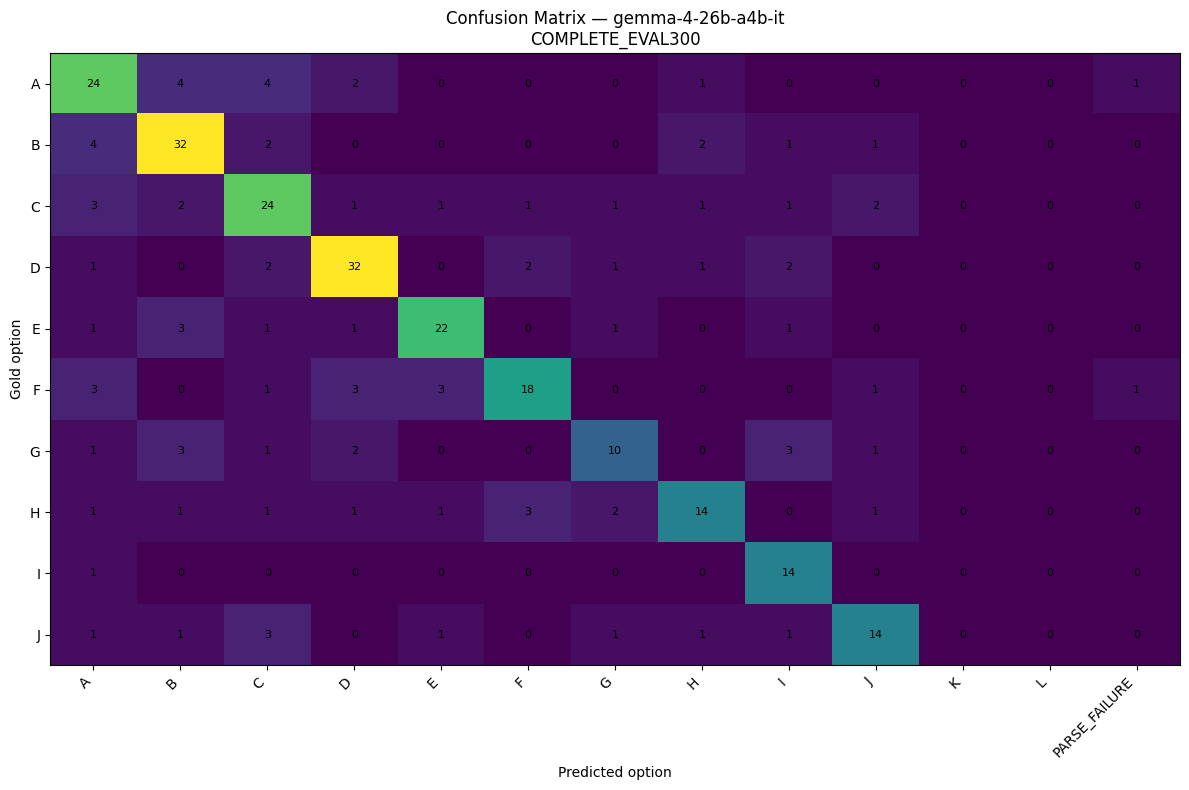

In [23]:
if n_valid:
    max_choices_observed = int(results['n_options'].max())
    observed_choice_labels = choice_letters(max_choices_observed)
    labels = observed_choice_labels + ['PARSE_FAILURE']

    cm = confusion_matrix(yt, yp, labels=labels)

    # Gold labels occupy only rows actually present in the dataset.
    gold_labels_present = [
        label for label in observed_choice_labels
        if label in set(yt)
    ]
    row_indices = [labels.index(label) for label in gold_labels_present]
    cm_display = cm[row_indices, :]

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(cm_display, aspect='auto')

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticks(range(len(gold_labels_present)))
    ax.set_yticklabels(gold_labels_present)

    ax.set_xlabel('Predicted option')
    ax.set_ylabel('Gold option')
    ax.set_title(f'Confusion Matrix — {MODEL}\n{status}')

    for i in range(cm_display.shape[0]):
        for j in range(cm_display.shape[1]):
            ax.text(
                j, i, str(cm_display[i, j]),
                ha='center', va='center', fontsize=8
            )

    fig.tight_layout()
    fig.savefig(
        PLOTS_DIR / 'confusion_matrix.png',
        dpi=180,
        bbox_inches='tight',
    )
    plt.show()

# 19. Two-stage runtime, throughput, token, and output-length metrics


In [24]:
def num(series):
    return pd.to_numeric(series, errors="coerce")


def safe_sum(frame, column):
    return float(num(frame[column]).fillna(0).sum()) if len(frame) and column in frame else 0.0


answer_prompt_tokens = safe_sum(results, "prompt_tokens")
answer_completion_tokens = safe_sum(results, "completion_tokens")
answer_total_tokens = safe_sum(results, "total_tokens")
answer_latency_s = safe_sum(results, "latency_s")
plan_prompt_tokens = safe_sum(plan_results, "prompt_tokens")
plan_completion_tokens = safe_sum(plan_results, "completion_tokens")
plan_total_tokens = safe_sum(plan_results, "total_tokens")
plan_latency_s = safe_sum(plan_results, "latency_s")

eff = {
    "successful_plan_calls": int(n_plan_valid),
    "successful_final_answer_calls": int(n_valid),
    "successful_calls_total": int(n_plan_valid + n_valid),
    "plan_prompt_tokens": plan_prompt_tokens,
    "plan_completion_tokens": plan_completion_tokens,
    "plan_total_tokens": plan_total_tokens,
    "final_answer_prompt_tokens": answer_prompt_tokens,
    "final_answer_completion_tokens": answer_completion_tokens,
    "final_answer_total_tokens": answer_total_tokens,
    "p3_total_prompt_tokens": plan_prompt_tokens + answer_prompt_tokens,
    "p3_total_completion_tokens": plan_completion_tokens + answer_completion_tokens,
    "p3_total_tokens": plan_total_tokens + answer_total_tokens,
    "plan_successful_latency_s": plan_latency_s,
    "final_answer_successful_latency_s": answer_latency_s,
    "p3_successful_latency_s": plan_latency_s + answer_latency_s,
    "p3_total_tokens_per_completed_item": (
        (plan_total_tokens + answer_total_tokens) / n_valid if n_valid else np.nan
    ),
    "plan_truncation_rate": float(plan_results["truncated"].mean()) if n_plan_valid else np.nan,
    "plan_answer_leakage_rate": (
        float(plan_results["plan_answer_leakage_detected"].mean())
        if n_plan_valid else np.nan
    ),
    "final_answer_truncation_rate": float(results["truncated"].mean()) if n_valid else np.nan,
    "mean_plan_completion_tokens": (
        float(num(plan_results["completion_tokens"]).mean()) if n_plan_valid else np.nan
    ),
    "mean_final_answer_completion_tokens": (
        float(num(results["completion_tokens"]).mean()) if n_valid else np.nan
    ),
}
display(pd.DataFrame([eff]).T.rename(columns={0: "value"}).round(5))


,value
successful_plan_calls,3.000000e+02
successful_final_answer_calls,3.000000e+02
successful_calls_total,6.000000e+02
plan_prompt_tokens,1.444750e+05
plan_completion_tokens,2.922470e+05
plan_total_tokens,4.367220e+05
final_answer_prompt_tokens,4.526220e+05
final_answer_completion_tokens,1.757040e+05
final_answer_total_tokens,6.283260e+05
p3_total_prompt_tokens,5.970970e+05


# 20. Latency and completion-token distributions


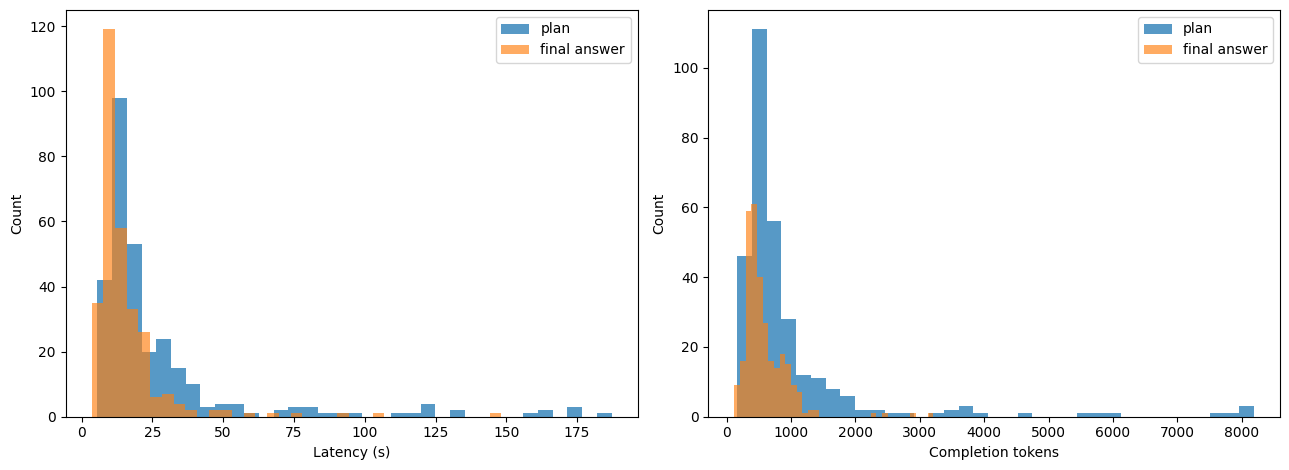

In [25]:
if n_plan_valid or n_valid:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    if n_plan_valid:
        axes[0].hist(num(plan_results["latency_s"]).dropna(), bins=35, alpha=.75, label="plan")
        axes[1].hist(num(plan_results["completion_tokens"]).dropna(), bins=35, alpha=.75, label="plan")
    if n_valid:
        axes[0].hist(num(results["latency_s"]).dropna(), bins=35, alpha=.65, label="final answer")
        axes[1].hist(num(results["completion_tokens"]).dropna(), bins=35, alpha=.65, label="final answer")
    axes[0].set_xlabel("Latency (s)")
    axes[0].set_ylabel("Count")
    axes[0].legend()
    axes[1].set_xlabel("Completion tokens")
    axes[1].set_ylabel("Count")
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "latency_completion_distributions.png", dpi=180)
    plt.show()


# 21. Subject, domain, difficulty, image-type and image-count analyses


In [26]:
DOMAIN={'Art and Design':['Art','Art_Theory','Design','Music'],'Business':['Accounting','Economics','Finance','Manage','Marketing'],
 'Science':['Biology','Chemistry','Geography','Math','Physics'],'Health and Medicine':['Basic_Medical_Science','Clinical_Medicine','Diagnostics_and_Laboratory_Medicine','Pharmacy','Public_Health'],
 'Humanities and Social Science':['History','Literature','Sociology','Psychology'],'Tech and Engineering':['Agriculture','Architecture_and_Engineering','Computer_Science','Electronics','Energy_and_Power','Materials','Mechanical_Engineering']}
S2D={s:d for d,ss in DOMAIN.items() for s in ss}
def group_acc(df,col): return df.groupby(col,dropna=False).agg(n=('sample_id','size'),correct=('strict_correct','sum'),accuracy=('strict_correct','mean'),mean_latency_s=('latency_s','mean'),mean_completion_tokens=('completion_tokens','mean')).reset_index()
if n_valid:
    results['domain']=results['subject'].map(S2D).fillna('Other/Unmapped')
    subject=group_acc(results,'subject'); domain=group_acc(results,'domain'); diff=group_acc(results,'topic_difficulty'); imgt=group_acc(results,'img_type'); imgc=group_acc(results,'image_count')
    subject.to_csv(SUBJECT_CSV,index=False); domain.to_csv(DOMAIN_CSV,index=False); diff.to_csv(DIFF_CSV,index=False); imgt.to_csv(IMGTYPE_CSV,index=False); imgc.to_csv(IMGCOUNT_CSV,index=False)
    print('Domain'); display(domain.round(4)); print('Difficulty'); display(diff.round(4)); print('Image count'); display(imgc.round(4)); print('Subject'); display(subject.round(4))

Domain


,domain,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,Art and Design,40,22,0.5500,9.3157,365.0750
1,Business,50,40,0.8000,20.3515,683.4800
2,Health and Medicine,50,29,0.5800,10.9311,407.3800
3,Humanities and Social Science,40,27,0.6750,11.3311,424.1500
4,Science,50,31,0.6200,13.9184,583.3400
5,Tech and Engineering,70,55,0.7857,22.6927,863.2143


Difficulty


,topic_difficulty,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,Easy,88,64,0.7273,14.4894,503.4091
1,Hard,88,59,0.6705,16.6403,659.8409
2,Medium,124,81,0.6532,15.6048,591.4355


Image count


,image_count,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,1,278,190,0.6835,15.7358,589.7374
1,2,12,10,0.8333,13.9882,506.0000
2,3,1,1,1.0000,13.8684,619.0000
3,4,5,1,0.2000,10.9735,444.2000
4,5,4,2,0.5000,15.8150,711.2500


Subject


,subject,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,Accounting,10,7,0.7,14.2525,642.6
1,Agriculture,10,8,0.8,16.4987,392.2
2,Architecture_and_Engineering,10,9,0.9,30.6921,1392.2
3,Art,10,5,0.5,9.1121,322.9
4,Art_Theory,10,8,0.8,8.5553,347.1
5,Basic_Medical_Science,10,6,0.6,12.2547,336.3
6,Biology,10,3,0.3,12.6023,551.7
7,Chemistry,10,6,0.6,11.9252,520.7
8,Clinical_Medicine,10,7,0.7,8.8980,370.6
9,Computer_Science,10,7,0.7,22.0753,701.4


# 22. Answer-position bias diagnostics


,letter,gold_count,predicted_count
0,A,36,40
1,B,42,46
2,C,37,39
3,D,41,42
4,E,30,28
5,F,30,24
6,G,21,16
7,H,25,20
8,I,15,23
9,J,23,20


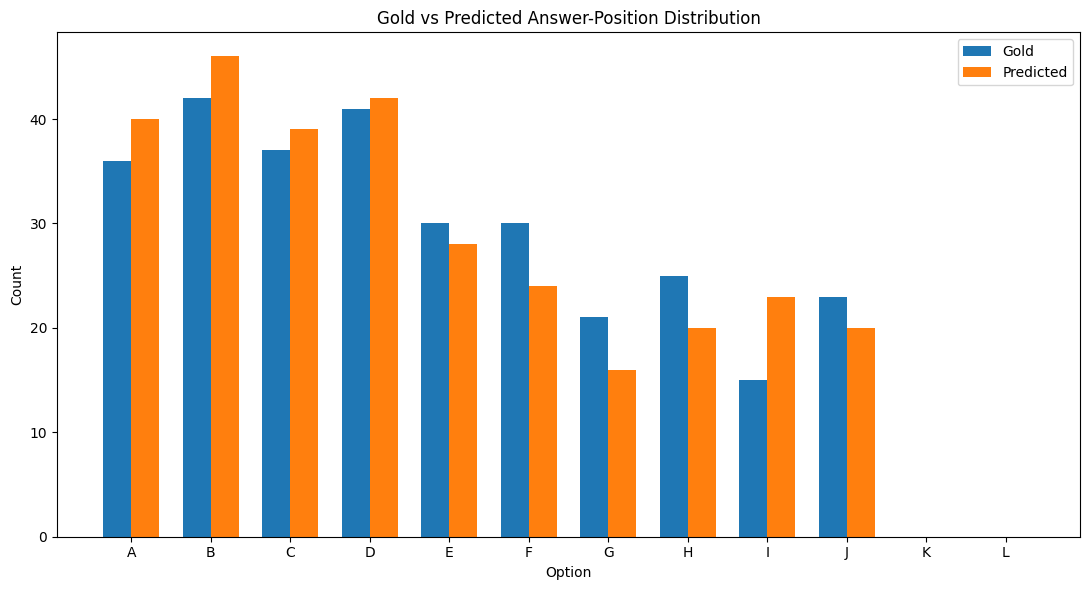

In [27]:
if n_valid:
    position_labels = choice_letters(int(results['n_options'].max()))

    g = results['gold_answer'].value_counts().reindex(position_labels, fill_value=0)
    p = results['strict_prediction'].value_counts().reindex(position_labels, fill_value=0)

    pos = pd.DataFrame({
        'letter': position_labels,
        'gold_count': g.values,
        'predicted_count': p.values,
    })
    display(pos)

    x = np.arange(len(position_labels))
    w = .35
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.bar(x - w/2, pos['gold_count'], w, label='Gold')
    ax.bar(x + w/2, pos['predicted_count'], w, label='Predicted')
    ax.set_xticks(x)
    ax.set_xticklabels(position_labels)
    ax.set_xlabel('Option')
    ax.set_ylabel('Count')
    ax.set_title('Gold vs Predicted Answer-Position Distribution')
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR/'answer_positions.png', dpi=180, bbox_inches='tight')
    plt.show()

# 23. Consolidated paper-ready summary


In [28]:
summary = {
    "analysis_status": status,
    "experiment_id": EXPERIMENT_ID,
    "experiment_signature": EXPERIMENT_SIGNATURE,
    "protocol_version": PROTOCOL_VERSION,
    "model": MODEL,
    "provider": PROVIDER,
    "api_method": API_METHOD,
    "api_version": API_VERSION,
    "sdk_pin": SDK_PIN,
    "dataset_revision": DATASET_REVISION,
    "n_dataset": n_total,
    "n_valid": n_valid,
    "n_missing": n_total - n_valid,
    "coverage": coverage,
    "expected_plan_calls": expected_plan_n,
    "n_plan_valid": n_plan_valid,
    "plan_coverage": plan_coverage,
    "plan_truncation_rate": None if pd.isna(plan_truncation_rate) else float(plan_truncation_rate),
    "plan_answer_leakage_rate": None if pd.isna(plan_answer_leakage_rate) else float(plan_answer_leakage_rate),
    "final_answer_truncation_rate": None if pd.isna(trunc) else float(trunc),
    "strict_format_compliance": None if pd.isna(fmt) else float(fmt),
    "prompt_id": PROMPT_ID,
    "prompt_family": PROMPT_FAMILY,
    "plan_suffix_sha256": PLAN_SUFFIX_SHA256,
    "execution_suffix_sha256": EXECUTION_SUFFIX_SHA256,
    "plan_template_sha256": PLAN_TEMPLATE_SHA256,
    "final_answer_template_sha256": FINAL_ANSWER_TEMPLATE_SHA256,
    "parser_version": PARSER_VERSION,
    "parser_spec_sha256": PARSER_SPEC_SHA256,
    "selection_protocol": SELECTION_PROTOCOL_NAME,
    "selected_ids_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "source_rows": len(source_ds),
    "classification": classification,
    "efficiency": eff,
}
SUMMARY_JSON.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
flat_summary = {
    "analysis_status": status,
    "model": MODEL,
    "provider": PROVIDER,
    "api_method": API_METHOD,
    "dataset_revision": DATASET_REVISION,
    "n_dataset": n_total,
    "n_valid": n_valid,
    "n_missing": n_total - n_valid,
    "coverage": coverage,
    "expected_plan_calls": expected_plan_n,
    "n_plan_valid": n_plan_valid,
    "plan_coverage": plan_coverage,
    **classification,
    **eff,
}
pd.DataFrame([flat_summary]).to_csv(SUMMARY_CSV, index=False)
display(pd.DataFrame([flat_summary]).T.rename(columns={0: "value"}))


,value
analysis_status,COMPLETE_EVAL300
model,gemma-4-26b-a4b-it
provider,Google Gemini Developer API / AI Studio Free Tier
api_method,google-genai client.models.generate_content
dataset_revision,563f3e84bb3b90893083a1f039cfa13077f2302b
n_dataset,300
n_valid,300
n_missing,0
coverage,1.0
expected_plan_calls,300


# 24. Professional qualitative audit viewer


In [29]:
def br(x): return html.escape(str(x or "")).replace("\n", "<br>")
if GENERATE_HTML_AUDIT and n_valid:
    cards = []
    for _, r in results.sort_values("execution_order").iterrows():
        imgs = "".join(
            f'<img src="{html.escape(p)}" style="max-width:420px;max-height:320px;margin:6px;border:1px solid #ddd">'
            for p in str(r["image_files"]).split(";") if p
        )
        opts = json.loads(r["options_json"])
        ol = '<ol type="A">' + "".join(f"<li>{html.escape(str(o))}</li>" for o in opts) + "</ol>"
        verdict = "CORRECT" if bool(r["strict_correct"]) else "WRONG"
        cards.append(f"""<section style="border:1px solid #bbb;padding:16px;margin:18px 0"><h2>{html.escape(str(r['sample_id']))} — {verdict}</h2>
        <p><b>Subject:</b> {html.escape(str(r['subject']))}<br><b>Strict prediction:</b> {html.escape(str(r['strict_prediction']))}<br><b>Gold:</b> {html.escape(str(r['gold_answer']))} — {html.escape(str(r['gold_option_text']))}</p>
        <div>{imgs}</div><h3>Call-1 plan supplied verbatim to call 2</h3><div style="background:#eef6ff;padding:10px">{br(r['plan_text'])}</div><h3>Question</h3><p>{br(r['question'])}</p><h3>Options</h3>{ol}<h3>Call-2 visible response</h3><div style="background:#f6f6f6;padding:10px">{br(r['visible_response'])}</div>
        <h3>Model-provided reasoning field</h3><div style="background:#fafafa;padding:10px">{br(r['reasoning_content'])}</div><h3>Gold explanation — intentionally excluded from inference records</h3><div style="background:#fff9e8;padding:10px">{br(r['gold_explanation'])}</div></section>""")
    doc = f'<!doctype html><html><head><meta charset="utf-8"><title>{EXPERIMENT_ID}</title></head><body style="font-family:Arial;max-width:1200px;margin:auto;padding:20px"><h1>{EXPERIMENT_ID}</h1><p><b>Status:</b> {status}; {n_valid}/{n_total}</p>' + "".join(cards) + "</body></html>"
    AUDIT_HTML.write_text(doc, encoding="utf-8")
    print("Saved", AUDIT_HTML)


Saved /kaggle/working/gemma4_26b_a4b_p3_two_call_plan_solve_google_api_eval300_MAX8192_v1/audit_viewer.html


# 25. README_RESULTS.md and final completion gate


In [30]:
def pct(value):
    return "N/A" if value is None or pd.isna(value) else f"{100*float(value):.2f}%"

readme = f"""# {EXPERIMENT_ID}

## Status
**{status}** — final answers {n_valid}/{n_total}; plans {n_plan_valid}/{expected_plan_n}.

## P3 method
- call 1 receives the complete multimodal question and the planning trigger
- call 2 receives the complete multimodal question again plus the raw call-1 plan
- only call 2 is scored
- both calls preserve exact numbered-marker occurrence order
- repeated references repeat the same source image at every occurrence
- successful call-1 content is injected verbatim, including truncation or answer leakage
- P3 is reported as a two-call Plan-and-Solve adaptation

## Dataset
- `{DATASET_REPO}` / `{DATASET_CONFIG}` / `{DATASET_SPLIT}`
- revision `{DATASET_REVISION}`
- selected IDs SHA256 `{SELECTED_IDS_CANONICAL_SHA256}`
- 300 rows, 30 subjects, 10 items per subject

## Hosted model and generation — both calls
- endpoint `{MODEL}`
- provider `{PROVIDER}`
- API `{API_METHOD}`, version `{API_VERSION}`
- SDK `{SDK_PIN}`
- temperature `{TEMPERATURE}`; top-p/top-k not sent
- max output tokens `{MAX_TOKENS}` per call; seed `{API_SEED}`
- thinking level `{THINKING_LEVEL}`; streaming `{STREAM}`
- context policy `{CTX_SIZE_POLICY}`
- no model weights or accelerator runtime are loaded

## Prompt hashes
- call-1 suffix `{PLAN_SUFFIX_SHA256}`
- call-1 canonical template `{PLAN_TEMPLATE_SHA256}`
- call-2 suffix `{EXECUTION_SUFFIX_SHA256}`
- call-2 canonical template `{FINAL_ANSWER_TEMPLATE_SHA256}`

## Scheduling and resume
- request timeout `{REQUEST_TIMEOUT_S}` seconds
- deferred retry timeout `{DEFERRED_REQUEST_TIMEOUT_S}` seconds
- audited attempts per pass `{MAX_ATTEMPTS}`
- inter-request delay `{INTER_REQUEST_DELAY_S}` seconds
- plans and final answers are checkpointed independently
- only missing stages are sent after exact-signature record validation
- valid truncated, answer-leaking and parse-failure outputs are retained

## Frozen scoring
- parser `{PARSER_VERSION}`
- parser SHA256 `{PARSER_SPEC_SHA256}`
- primary outcome: deterministic last-line answer accuracy on call 2
- no random fallback; truncated final answers are incorrect

## Headline results
- primary answer accuracy: {pct(classification.get('strict_accuracy'))}
- call-1 plan truncation rate: {pct(plan_truncation_rate)}
- call-1 answer-leakage rate: {pct(plan_answer_leakage_rate)}
- call-2 truncation rate: {pct(trunc)}
- total P3 tokens: {eff.get('p3_total_tokens', 'N/A')}

Final results are reportable only when both stages have complete coverage.
"""
README.write_text(readme, encoding="utf-8")
print(readme)


# MMMUPro-Eval300__Gemma4-26B-A4B-IT__P3-TwoCallPlanAndSolve__GoogleGeminiAPI__RawPlanInjection__ValidatedTwoStageResume__Temp0__Seed42__MAX8192

## Status
**COMPLETE_EVAL300** — final answers 300/300; plans 300/300.

## P3 method
- call 1 receives the complete multimodal question and the planning trigger
- call 2 receives the complete multimodal question again plus the raw call-1 plan
- only call 2 is scored
- both calls preserve exact numbered-marker occurrence order
- repeated references repeat the same source image at every occurrence
- successful call-1 content is injected verbatim, including truncation or answer leakage
- P3 is reported as a two-call Plan-and-Solve adaptation

## Dataset
- `MMMU/MMMU_Pro` / `standard (10 options)` / `test`
- revision `563f3e84bb3b90893083a1f039cfa13077f2302b`
- selected IDs SHA256 `db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3`
- 300 rows, 30 subjects, 10 items per subject

## Hosted model and generation — both calls
- endpoint

In [31]:
# 26. Suggested Methods wording for the P3 experiment

methods = f"""
We evaluated a two-call Plan-and-Solve adaptation (P3) using the hosted
`{MODEL}` endpoint on the frozen balanced MMMU-Pro Eval300 cohort. In call 1,
the complete multimodal multiple-choice problem was followed by the planning
trigger: `{PLAN_SUFFIX}`. The raw visible call-1 response was checkpointed and
inserted without semantic editing into call 2. Call 2 received the complete
problem and images again, followed by the stored plan and the frozen execution
and answer scaffold. Only the final response from call 2 was scored. We refer
to this condition as a two-call adaptation rather than an exact replication of
the original single-generation Plan-and-Solve protocol.

Both calls followed the original numbered image-marker occurrence order. Each
occurrence consisted of a semantic label immediately followed by the matching
lossless PNG image Part. Repeated references repeated the same source image at
each occurrence. Gold answers and reference explanations were never supplied.

Both calls used Google Gemini Developer API method `{API_METHOD}`, endpoint
`{MODEL}`, SDK `{SDK_PIN}`, API version `{API_VERSION}`, temperature 0, fixed
seed 42, no explicit top-p or top-k, a {MAX_TOKENS}-token output limit per call,
non-streaming generation and `thinking_level="{THINKING_LEVEL}"`. Context size
was provider managed; no explicit context-size parameter was sent.

Ordinary API attempts used a {REQUEST_TIMEOUT_S}-second transport timeout. A
sample with an infrastructure failure or timeout remained incomplete and was
retried after the main pass with a {DEFERRED_REQUEST_TIMEOUT_S}-second timeout;
this changed neither prompt nor generation settings. Plans and final answers
were checkpointed independently. Resume required an exact experiment signature
and record-level validation, including prompt hashes, image hashes, occurrence
order and the hash of the injected plan. A successful provider response was
never regenerated based on content quality, truncation or answer leakage.

Headline accuracy used frozen parser `{PARSER_VERSION}`, which accepts an
answer only from the last non-empty line and has no random fallback. Truncated
final responses and format failures were counted as incorrect. Results were
designated final only after complete coverage of both stages. Call counts,
token usage and latency were reported for planning and execution separately.
""".strip()
print(methods)
(WORKDIR / "METHODS_SUGGESTION.txt").write_text(methods + "\n", encoding="utf-8")


We evaluated a two-call Plan-and-Solve adaptation (P3) using the hosted
`gemma-4-26b-a4b-it` endpoint on the frozen balanced MMMU-Pro Eval300 cohort. In call 1,
the complete multimodal multiple-choice problem was followed by the planning
trigger: `A: Let's first understand the problem and devise a plan to solve the problem.`. The raw visible call-1 response was checkpointed and
inserted without semantic editing into call 2. Call 2 received the complete
problem and images again, followed by the stored plan and the frozen execution
and answer scaffold. Only the final response from call 2 was scored. We refer
to this condition as a two-call adaptation rather than an exact replication of
the original single-generation Plan-and-Solve protocol.

Both calls followed the original numbered image-marker occurrence order. Each
occurrence consisted of a semantic label immediately followed by the matching
lossless PNG image Part. Repeated references repeated the same source image at
each occurrence

2455